# Two-Electron 2D Schrödinger Solver — DVR / CI / RL


| Section | Content |
|:--------|:--------|
| 0 | Imports and physical parameters |
| 1 | Discrete Variable Representation (DVR) |
| 2 | Double-well potential |
| 3 | Single-particle eigenstates |
| 4 | Slater-determinant basis (energy-sorted — bug fix) |
| 5 | Coulomb kernel |
| 6 | CI Hamiltonian and two-electron spectrum |
| 7 | Spin, entanglement and orbital localisation |
| 8 | Quantum sensing |

<br>   

>
> **Bug fixed in this version:** the original code used an index-ordered Slater basis
> truncated at `n_compute = 40`, silently excluding all `(L_excited, R)` configurations
> such as `(L1, R0)`, `(L2, R0)` even though their one-body energy matches included
> `(L0, R_excited)` states.  The fix — `build_slater_basis_sorted` +
> `N_CI_COMPUTE = 200` — is demonstrated in Section 4.


---
## Section 0 — Imports and Physical Parameters

In [1]:
%matplotlib inline
import numpy as np
from scipy.linalg import eigh
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Physical / grid parameters (same as main())
Nx, Ny   = 20, 20
x0, xL   = -1.0,  1.0
y0, yL   = -0.5,  0.5
params   = {'a': 0.6, 'k': 1000.0, 'ky': 1500.0, 'delta': 0.0, 'd': 1.0}
kappa    = 2326.0    # Coulomb strength (Mott-Hubbard crossover, U/t ~ 1) -> How is this chosen?
epsilon  = 0.01       # Coulomb softening length
Nstates  = 40        # SP orbitals to retain

print(f"Grid     : {Nx}x{Ny} = {Nx*Ny} points  [{x0},{xL}] x [{y0},{yL}]")
print(f"kappa    : {kappa}")
print(f"epsilon  : {epsilon}")
print(f"Nstates  : {Nstates}")


Grid     : 20x20 = 400 points  [-1.0,1.0] x [-0.5,0.5]
kappa    : 2326.0
epsilon  : 0.01
Nstates  : 40


---
## Section 1 — Discrete Variable Representation (DVR)

The sine-DVR maps $[x_0, x_L]$ onto $N$ grid points and returns the exact
kinetic-energy matrix in the DVR basis.  The 2-D kinetic matrix is a
Kronecker sum:

$$T_{2D} = T_x \otimes I_y + I_x \otimes T_y$$


In [2]:
def sine_dvr_1d(x0, xL, N):
    """1-D sine-DVR on [x0, xL] with N grid points.  hbar^2/2m = 1."""
    L = xL - x0
    x = x0 + np.arange(1, N + 1) * L / (N + 1)
    w = np.full(N, L / (N + 1))
    j = np.arange(1, N + 1)
    U = np.sqrt(2 / (N + 1)) * np.sin(np.outer(j, j * np.pi / (N + 1)))
    T = (U.T * (j * np.pi / L) ** 2) @ U
    return x, w, T


def build_2d_dvr(Nx=20, Ny=20, x0=-1.0, xL=1.0, y0=-0.5, yL=0.5):
    xg, wx, Tx = sine_dvr_1d(x0, xL, Nx)
    yg, wy, Ty = sine_dvr_1d(y0, yL, Ny)
    T2D = np.kron(Tx, np.eye(Ny)) + np.kron(np.eye(Nx), Ty)
    return xg, yg, wx, wy, T2D


x_grid, y_grid, w_x, w_y, T2D = build_2d_dvr(Nx, Ny, x0, xL, y0, yL)
print(f"DVR grid : {Nx}x{Ny} = {Nx*Ny} points")
print(f"T2D shape: {T2D.shape}")


DVR grid : 20x20 = 400 points
T2D shape: (400, 400)


---
## Section 2 — Double-Well Potential

$$V(x,y) = k\left[\left(\frac{x}{d}\right)^2 - a^2\right]^2
           + \delta\,x + \tfrac{1}{2}k_y\,y^2$$

Wells sit at $x = \pm a\,d$.  The linear tilt $\delta$ introduces asymmetry.


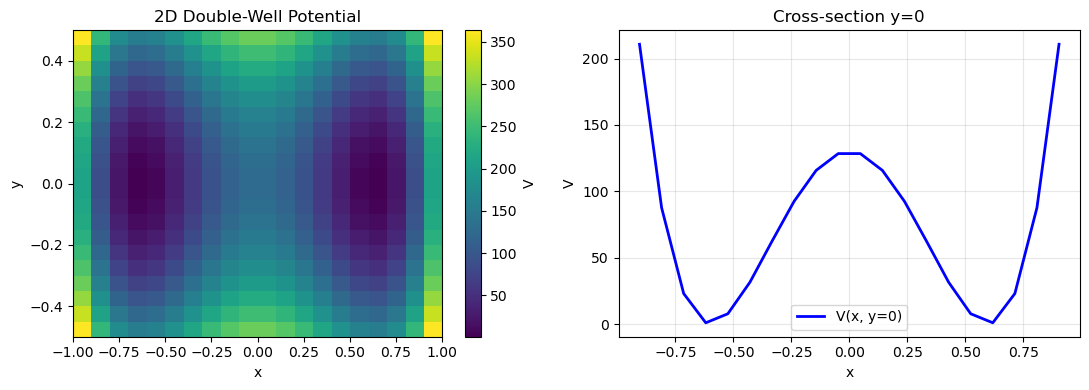

Well minima at x = +/-0.600


In [3]:
def double_well_potential(x, y, params):
    a     = params.get('a',     1.0)
    k     = params.get('k',    50.0)
    ky    = params.get('ky',  100.0)
    delta = params.get('delta', 0.5)
    d     = params.get('d',     1.0)
    return k * ((x / d)**2 - a**2)**2 + delta * x + 0.5 * ky * y**2


def build_potential_matrix(x_grid, y_grid, params):
    X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
    V    = double_well_potential(X, Y, params).ravel()
    return np.diag(V)


V2D = build_potential_matrix(x_grid, y_grid, params)

X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')
V2d  = double_well_potential(X, Y, params)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
im = ax1.imshow(V2d.T, origin='lower', extent=(x0, xL, y0, yL), aspect='auto', cmap='viridis')
plt.colorbar(im, ax=ax1, label='V')
ax1.set(title='2D Double-Well Potential', xlabel='x', ylabel='y')
ax2.plot(x_grid, V2d[:, Ny // 2], 'b-', lw=2, label='V(x, y=0)')
ax2.set(title='Cross-section y=0', xlabel='x', ylabel='V')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('nb_potential.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Well minima at x = +/-{params['a'] * params['d']:.3f}")


---
## Section 3 — Single-Particle Eigenstates

Diagonalise $H_{sp} = T_{2D} + V_{2D}$ for the single-electron spectrum
$\varepsilon_k$, $\psi_k$.


In [4]:
def single_particle_eigenstates(T2D, V2D, Nstates=40):
    e_vals, e_vecs = eigh(T2D + V2D)
    return e_vals[:Nstates], e_vecs[:, :Nstates]


print("Diagonalising single-particle Hamiltonian...")
single_energies, single_vecs = single_particle_eigenstates(T2D, V2D, Nstates)

print("\nLowest 10 single-particle energies:")
for i, e in enumerate(single_energies[:10]):
    print(f"  psi_{i:2d}  E = {e:10.4f}")


Diagonalising single-particle Hamiltonian...

Lowest 10 single-particle energies:
  psi_ 0  E =    63.9667
  psi_ 1  E =    64.0289
  psi_ 2  E =   120.3798
  psi_ 3  E =   120.4420
  psi_ 4  E =   127.3519
  psi_ 5  E =   130.8141
  psi_ 6  E =   170.5505
  psi_ 7  E =   182.3630
  psi_ 8  E =   182.4252
  psi_ 9  E =   183.7650


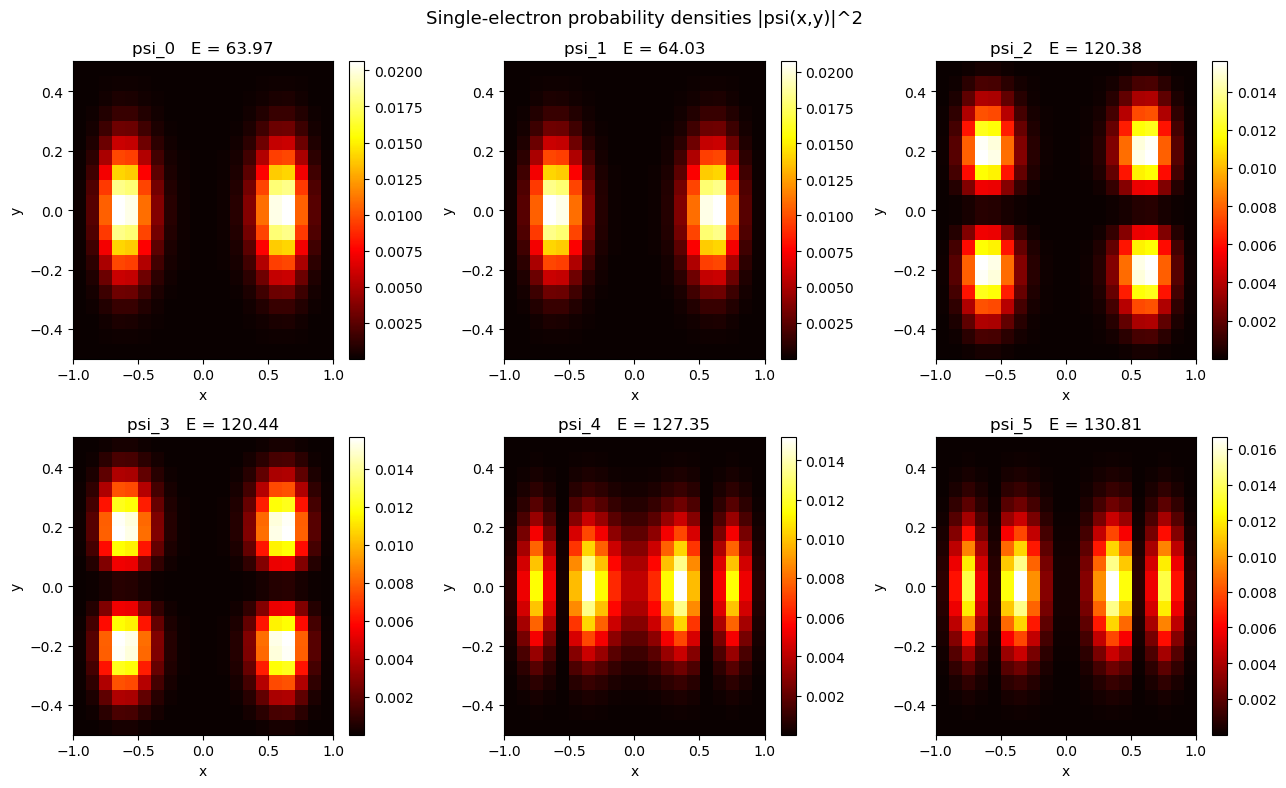

In [5]:
# Plot |psi|^2 for lowest 6 states
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i, ax in enumerate(axes.flatten()):
    Z  = np.abs(single_vecs[:, i].reshape(Nx, Ny))**2
    im = ax.imshow(Z.T, origin='lower', extent=(x0, xL, y0, yL), aspect='auto', cmap='hot')
    ax.set(title=f'psi_{i}   E = {single_energies[i]:.2f}', xlabel='x', ylabel='y')
    plt.colorbar(im, ax=ax)
plt.suptitle("Single-electron probability densities |psi(x,y)|^2", fontsize=13)
plt.tight_layout()
plt.savefig('nb_sp_states.png', dpi=120, bbox_inches='tight')
plt.show()


---
### Section 3.1 — Localised Single-Particle Basis (Left/Right) via Projectors (FPM)

The single-particle eigenstates $\psi_k$ of $H_sp$ are typically delocalised across
the two wells.  For site (well) entanglement and Hubbard-like modelling it is
useful to rotate the lowest M eigenstates into an orthonormal set of
left- and right-localised orbitals.

We implement the robust "projector method":
 1) choose a low-energy subspace spanned by {$\psi_k$}_{k=0..M-1}
 2) define a left projector $P_L(x,y)$ (hard or smooth cut at x = x_cut)
 3) form $P_{ij} = \braket{\psi_i | P_L | \psi_j}$ in that subspace
 4) diagonalise P: eigenvalues near 1 -> left-localised, near 0 -> right-localised

This yields localised orbitals $\phi_\mu(x,y) = \sum_k U_{loc}[k,\mu] \psi_k(x,y)$
within the chosen subspace.

In [6]:
def build_left_projector_mask(x_grid, y_grid, x_cut=0.0, smooth=False, sigma=0.02):
    """
    Return P_L(x,y) on the DVR grid as a flattened array in [0,1].

    If smooth=False: hard step at x_cut.
    If smooth=True : smooth Fermi-type step of width sigma.
    """
    X, _ = np.meshgrid(x_grid, y_grid, indexing='ij')
    if not smooth:
        PL = (X < x_cut).astype(float)
    else:
        PL = 1.0 / (1.0 + np.exp((X - x_cut) / sigma))
    return PL.ravel()

def localise_orbitals_projector_DVR(single_vecs, x_grid, y_grid,
                                    M=16, x_cut=0.0, smooth=True, sigma=0.03):
    PLg = build_left_projector_mask(x_grid, y_grid, x_cut=x_cut,
                                    smooth=smooth, sigma=sigma)   # (G,)
    V = np.asarray(single_vecs[:, :M], dtype=complex)             # (G,M)

    # Psub_ij = <psi_i | PL | psi_j> in the DVR inner product
    Psub = V.conj().T @ (PLg[:, None] * V)

    lam, U = eigh((Psub + Psub.conj().T) / 2.0)
    idx = np.argsort(lam)[::-1]
    lam, U = lam[idx], U[:, idx]

    vecs_loc = V @ U
    labels = np.array(['L' if l > 0.5 else 'R' for l in lam], dtype=object)

    # sanity: orthonormality in DVR inner product
    S = vecs_loc.conj().T @ vecs_loc
    return U, vecs_loc, lam, labels, S


In [ ]:
M_LOC=32
X_CUT = 0.0
SMOOTH_PL = False
SIGMA_PL = 0.02
LAM_AMBIG_TOL = 0.05  # states with |lambda-0.5| <= tol are tagged ambiguous


U_loc, vecs_loc, lam_loc, lr_labels, S_ortho = localise_orbitals_projector_DVR(
    single_vecs, x_grid, y_grid,
    M=M_LOC, x_cut=X_CUT, smooth=SMOOTH_PL, sigma=SIGMA_PL
)

ambiguous_mu = np.where(np.abs(lam_loc - 0.5) <= LAM_AMBIG_TOL)[0].tolist()
n_left  = int(np.sum(lr_labels == 'L'))
n_right = int(np.sum(lr_labels == 'R'))

print("lam range:", lam_loc.min(), lam_loc.max())
print("||S-I||_max =", np.max(np.abs(S_ortho - np.eye(M_LOC))))
print(f"L/R counts (strict 0.5 split): L={n_left}, R={n_right}")
print(f"Ambiguous orbitals (|lambda-0.5| <= {LAM_AMBIG_TOL:.3f}): {len(ambiguous_mu)}")
if ambiguous_mu:
    print("  indices:", ambiguous_mu[:12], "..." if len(ambiguous_mu) > 12 else "")

lam range: 1.6997523531185907e-14 0.9999999999999847
||S-I||_max = 1.6775469902086115e-13
L/R counts (strict 0.5 split): L=15, R=17
Ambiguous orbitals (|lambda-0.5| <= 0.050): 2
  indices: [15, 16] 


In [8]:
def plot_localised_orbitals(vecs_loc, Nx, Ny,
                            x0, xL, y0, yL,
                            lam=None, labels=None,
                            idx_list=None, n_show=6,
                            cmap='hot', savepath=None):

    M = vecs_loc.shape[1]

    if idx_list is None:
        idx_list = list(range(min(n_show, M)))
    else:
        idx_list = list(idx_list)

    n_show = len(idx_list)
    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 8))
    axes = axes.ravel()

    for j, ax in enumerate(axes):
        if j >= n_show:
            ax.axis('off')
            continue

        mu = idx_list[j]
        Z = np.abs(vecs_loc[:, mu].reshape(Nx, Ny))**2
        im = ax.imshow(Z.T, origin='lower', extent=(x0, xL, y0, yL),
                       aspect='auto', cmap=cmap)

        title = f'phi_{mu}'
        if lam is not None:
            title += f'  lam={float(lam[mu]):.3f}'
        if labels is not None:
            title += f'  ({labels[mu]})'
        ax.set_title(title)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=120, bbox_inches='tight')
    plt.show()
    return 


32


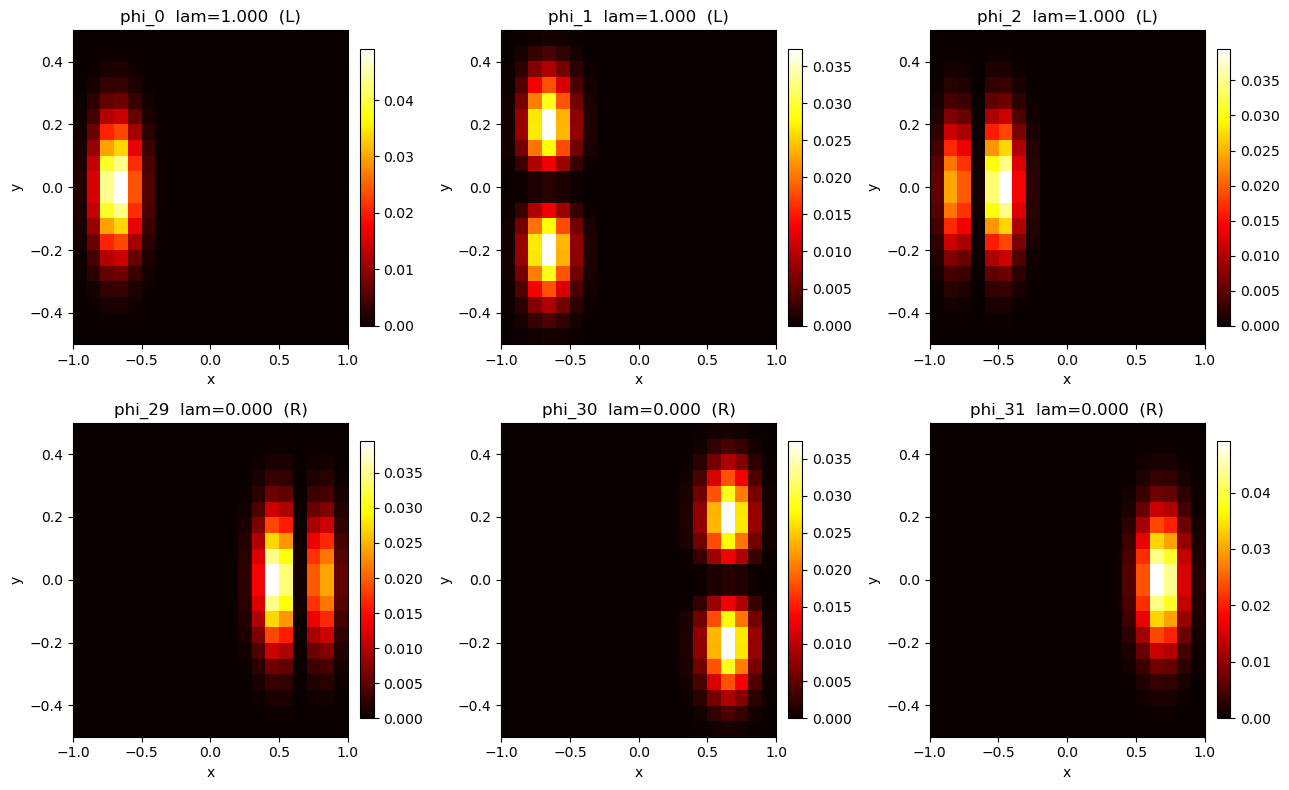

In [9]:
# Localised orbitals: show 3 most L and 3 most R (by lam value)
M = vecs_loc.shape[1]
print(M)
idx = list(range(0,3)) + list(range(M-3, M))
plot_localised_orbitals(vecs_loc, Nx, Ny, x0, xL, y0, yL,
                        lam=lam_loc, labels=lr_labels,
                        idx_list=idx)

---
## Section 4 — Slater-Determinant Basis (energy-sorted — bug fix) for two electrons

### The original bug

`build_slater_basis()` ordered pairs as `(0,0),(0,1),...,(0,Nb-1),(1,1),(1,2),...`
so truncating to `n_compute = 40` kept only pairs involving orbital 0.
In the double-well this meant every `(L_excited, R)` configuration —
`(L1,R0)`, `(L2,R0)`, … — was absent from the CI despite having the same
one-body energy as the included `(L0, R_excited)` states.

| Basis index (old) | Config | $E_a+E_b$ | In n=40? |
|:---:|:---:|:---:|:---:|
| 1 | (L0, R0) | 128 | YES |
| 37 | (L0, R4) | 249 | YES (last) |
| **158** | **(L1, R0)** | **184** | **NO — cut off** |
| **166** | **(L2, R0)** | **193** | **NO — cut off** |

### The fix

`build_slater_basis_sorted()` sorts by $E_a+E_b$ so all configurations
in the energy window enter the CI regardless of orbital index.
`N_CI_COMPUTE = 200` covers L0–L4 × R0–R4 comfortably.


In [10]:
def build_slater_basis(Nb):
    """Original index-ordered basis (kept for reference/backward compatibility)."""
    basis = []
    for a in range(Nb):
        for b in range(a, Nb):
            if a == b:
                basis.append((a, b, 'ud', 'singlet'))
            else:
                basis.append((a, b, 'singlet',   'singlet'))
                basis.append((a, b, 'uu',         'triplet_p'))
                basis.append((a, b, 'triplet_0',  'triplet_0'))
                basis.append((a, b, 'dd',         'triplet_m'))
    return basis


def build_slater_basis_sorted(Nb, single_energies):
    """
    Energy-sorted Slater basis.

    Sorts all (a,b) orbital pairs by E_a + E_b before returning, so that
    truncating to n_compute determinants captures all configurations in
    the lowest energy window -- including L-excited (1,1) states such as
    (L1,R0) that the index-ordered basis placed at index >= 158.
    """
    raw = []
    for a in range(Nb):
        for b in range(a, Nb):
            Eab = float(single_energies[a]) + float(single_energies[b])
            if a == b:
                raw.append((Eab, a, b, 'ud',        'singlet'))
            else:
                raw.append((Eab, a, b, 'singlet',   'singlet'))
                raw.append((Eab, a, b, 'uu',        'triplet_p'))
                raw.append((Eab, a, b, 'triplet_0', 'triplet_0'))
                raw.append((Eab, a, b, 'dd',        'triplet_m'))
    raw.sort(key=lambda x: (x[0], x[1], x[2]))
    return [(a, b, sc, st) for (_, a, b, sc, st) in raw]


N_CI_COMPUTE  = 200   # raised from 40; covers L0-L4 x R0-R4

old_basis    = build_slater_basis(Nstates)
sorted_basis = build_slater_basis_sorted(Nstates, single_energies)

print(f"Full basis size              : {len(old_basis)}")
print(f"n_compute used               : {N_CI_COMPUTE}")
print()
print("First 10 entries of energy-sorted basis:")
for i, (a, b, sc, st) in enumerate(sorted_basis[:10]):
    Eab = single_energies[a] + single_energies[b]
    print(f"  [{i:3d}]  ({a:2d},{b:2d})  {st:<12}  E_a+E_b = {Eab:.2f}")


Full basis size              : 3160
n_compute used               : 200

First 10 entries of energy-sorted basis:
  [  0]  ( 0, 0)  singlet       E_a+E_b = 127.93
  [  1]  ( 0, 1)  singlet       E_a+E_b = 128.00
  [  2]  ( 0, 1)  triplet_p     E_a+E_b = 128.00
  [  3]  ( 0, 1)  triplet_0     E_a+E_b = 128.00
  [  4]  ( 0, 1)  triplet_m     E_a+E_b = 128.00
  [  5]  ( 1, 1)  singlet       E_a+E_b = 128.06
  [  6]  ( 0, 2)  singlet       E_a+E_b = 184.35
  [  7]  ( 0, 2)  triplet_p     E_a+E_b = 184.35
  [  8]  ( 0, 2)  triplet_0     E_a+E_b = 184.35
  [  9]  ( 0, 2)  triplet_m     E_a+E_b = 184.35


In [11]:
# Orbital localisation helper (needed to show L-rank in demo below)
# For symmetric double well, these are delocalized
def orbital_localization(single_vecs, single_energies, x_grid, y_grid,
                          Nstates=200, loc_threshold=0.20):
    Nx, Ny = len(x_grid), len(y_grid)
    X2d, _ = np.meshgrid(x_grid, y_grid, indexing='ij')
    Xf     = X2d.ravel()
    prob   = np.abs(single_vecs[:, :Nstates])**2
    ex_all = Xf @ prob
    info   = []
    for idx in range(Nstates):
        ex = float(np.real(ex_all[idx]))
        if   ex < -loc_threshold: label, wc = "Left well",   'L'
        elif ex >  loc_threshold: label, wc = "Right well",  'R'
        else:                     label, wc = "Delocalized", 'D'
        info.append((idx, float(single_energies[idx]), ex, label, wc))
    return info


orbital_info = orbital_localization(single_vecs, single_energies,
                                     x_grid, y_grid, Nstates)

well   = {o[0]: o[4] for o in orbital_info}
L_orbs = sorted([o[0] for o in orbital_info if o[4]=='L'], key=lambda i: single_energies[i])
R_orbs = sorted([o[0] for o in orbital_info if o[4]=='R'], key=lambda i: single_energies[i])
rank_L = {orb: k for k, orb in enumerate(L_orbs)}
rank_R = {orb: k for k, orb in enumerate(R_orbs)}

print(f"L orbitals: {[f'L{k}=psi{orb}(E={single_energies[orb]:.1f})' for k,orb in enumerate(L_orbs[:5])]}")
print(f"R orbitals: {[f'R{k}=psi{orb}(E={single_energies[orb]:.1f})' for k,orb in enumerate(R_orbs[:5])]}")
print()

# Compare how the first (1,1) singlets appear in each ordering
print("First (1,1) singlets in each basis ordering:")
print(f"  {'Basis':>12}  {'Index':>6}  {'Config':>10}  {'E_a+E_b':>10}  In n=40?")
print("  " + "-"*52)
for bname, basis in [("index-ord.", old_basis), ("energy-sort", sorted_basis)]:
    shown = 0
    for idx, (a, b, sc, st) in enumerate(basis):
        if st != 'singlet': continue
        wa = well.get(a, 'D'); wb = well.get(b, 'D')
        if not ((wa=='L' and wb=='R') or (wa=='R' and wb=='L')): continue
        la = rank_L.get(a if wa=='L' else b, -1)
        Eab = single_energies[a] + single_energies[b]
        flag = "YES" if idx < 40 else "NO"
        print(f"  {bname:>12}  {idx:>6}  L{la}-R?  {Eab:>10.2f}  {flag}")
        shown += 1
        if shown >= 5: break


L orbitals: []
R orbitals: []

First (1,1) singlets in each basis ordering:
         Basis   Index      Config     E_a+E_b  In n=40?
  ----------------------------------------------------


---
## Section 5 — Coulomb Kernel

$$K[g_1, g_2] = \frac{w_{g_1}\,w_{g_2}\,\kappa}
                      {\sqrt{|\mathbf{r}_1-\mathbf{r}_2|^2+\varepsilon^2}}$$

Precomputed once as a $(G\times G)$ matrix.  All two-electron integrals
$(ac|bd)$ are then matrix-vector products against $K$.


In [12]:
def precompute_coulomb_kernel(x_grid, y_grid, wx, wy, kappa=1.0, epsilon=0.1):
    X, Y    = np.meshgrid(x_grid, y_grid, indexing='ij')
    Xf, Yf  = X.ravel(), Y.ravel()
    Wx, Wy  = np.meshgrid(wx, wy, indexing='ij')
    Wf      = (Wx * Wy).ravel()
    dx = Xf[:, None] - Xf[None, :]
    dy = Yf[:, None] - Yf[None, :]
    r12 = np.sqrt(dx**2 + dy**2 + epsilon**2)
    return kappa / r12 * Wf[:, None] * Wf[None, :]


print(f"Building Coulomb kernel (kappa={kappa}, epsilon={epsilon})...")
K = precompute_coulomb_kernel(x_grid, y_grid, w_x, w_y, kappa, epsilon)
print(f"K shape : {K.shape}  ({K.nbytes / 1e6:.1f} MB)")
print(f"K range : [{K.min():.3e}, {K.max():.3e}]")


Building Coulomb kernel (kappa=2326.0, epsilon=0.01)...
K shape : (400, 400)  (1.3 MB)
K range : [2.365e-02, 4.784e+00]


---
## Section 6 — CI Hamiltonian and Two-Electron Spectrum

Slater–Condon matrix element rules (Szabo & Ostlund §2.3):

| Element | Formula |
|:--------|:--------|
| $\langle aa\,S \| V \| aa\,S \rangle$ | $J(a,a)$ |
| $\langle ab\,S \| V \| ab\,S \rangle$ | $J(a,b)+K(a,b)$ |
| $\langle ab\,T \| V \| ab\,T \rangle$ | $J(a,b)-K(a,b)$ |
| $\langle aa\,S \| V \| bb\,S \rangle$ | $K_{ex}(a,b)$ |
| $\langle aa\,S \| V \| cd\,S \rangle$ | $\frac{1}{\sqrt{2}}(ac|ad)$ |
| $\langle ab\,S \| V \| cd\,S \rangle$ | $(ac|bd)+(ad|bc)$ |
| $\langle ab\,T \| V \| cd\,T \rangle$ | $(ac|bd)-(ad|bc)$ |


In [13]:
def build_ci_hamiltonian(slater_basis, single_energies, sv, K, n_compute=40):
    n  = min(n_compute, len(slater_basis))
    H  = np.zeros((n, n), dtype=complex)
    _te_cache = {}
    def te(a, b, c, d):
        key = (a, b, c, d)
        if key not in _te_cache:
            left  = np.conj(sv[:, a]) * sv[:, c]
            right = np.conj(sv[:, b]) * sv[:, d]
            _te_cache[key] = left @ K @ right
        return _te_cache[key]

    for I in range(n):
        a_I, b_I, _, stype_I = slater_basis[I]
        same_I = (a_I == b_I)
        for J in range(I, n):
            a_J, b_J, _, stype_J = slater_basis[J]
            if stype_I != stype_J:
                continue
            same_J = (a_J == b_J)
            val = 0.0 + 0.0j
            if I == J:
                val += single_energies[a_I] + single_energies[b_I]
            if stype_I == 'singlet':
                if same_I and same_J:
                    if a_I == a_J:
                        val += te(a_I, a_I, a_I, a_I)
                    else:
                        val += 2.0 * te(a_I, a_J, a_I, a_J)
                elif same_I:
                    val += np.sqrt(2.0) * te(a_I, a_J, a_I, b_J)
                elif same_J:
                    val += np.sqrt(2.0) * te(a_I, a_J, b_I, a_J)
                else:
                    val += te(a_I, a_J, b_I, b_J) + te(a_I, b_J, b_I, a_J)
            else:
                if not same_I and not same_J:
                    val += te(a_I, a_J, b_I, b_J) - te(a_I, b_J, b_I, a_J)
            H[I, J] += val
            if I != J:
                H[J, I] = np.conj(H[I, J])
    return 0.5 * (H + H.conj().T)


print(f"Building {N_CI_COMPUTE}x{N_CI_COMPUTE} CI Hamiltonian (energy-sorted basis)...")
slater_basis = build_slater_basis_sorted(Nstates, single_energies)
n_compute    = min(N_CI_COMPUTE, len(slater_basis))
H_slater     = build_ci_hamiltonian(slater_basis, single_energies,
                                     single_vecs, K, n_compute)
E2, C2 = eigh(H_slater)
print(f"Done.  n_compute = {n_compute},  lowest E = {E2[0]:.4f}")


Building 200x200 CI Hamiltonian (energy-sorted basis)...
Done.  n_compute = 200,  lowest E = 127.7779


In [14]:
# Config label helper
def cfg_label(a, b):
    wa = well.get(a, 'D'); wb = well.get(b, 'D')
    def lbl(idx, w):
        if w == 'L': return f"L{rank_L[idx]}"
        if w == 'R': return f"R{rank_R[idx]}"
        return f"D{idx}"
    return f"{lbl(a,wa)}-{lbl(b,wb)}"

_SPIN = {'singlet':(0.,0.),'triplet_p':(2.,1.),'triplet_0':(2.,0.),'triplet_m':(2.,-1.)}

print("Two-electron spectrum (lowest 20 states):")
print(f"  {'#':>3}  {'Energy':>10}  {'dE':>8}  {'Spin':>8}  {'Config':>10}")
print("  " + "-"*46)
for i in range(min(20, len(E2))):
    dom  = int(np.argmax(np.abs(C2[:, i])))
    a_d, b_d = slater_basis[dom][0], slater_basis[dom][1]
    weights = np.abs(C2[:, i])**2
    S2   = float(np.sum(weights * [_SPIN[slater_basis[j][3]][0] for j in range(n_compute)]))
    spin = 'Singlet' if S2 < 0.5 else 'Triplet'
    cfg  = cfg_label(a_d, b_d)
    print(f"  {i:>3}  {E2[i]:>10.4f}  {E2[i]-E2[0]:>8.4f}  {spin:>8}  {cfg:>10}")


Two-electron spectrum (lowest 20 states):
    #      Energy        dE      Spin      Config
  ----------------------------------------------
    0    127.7779    0.0000   Singlet       D0-D0
    1    127.9956    0.2177   Triplet       D0-D1
    2    127.9956    0.2177   Triplet       D0-D1
    3    127.9956    0.2177   Triplet       D0-D1
    4    128.3346    0.5567   Singlet       D0-D1
    5    128.6327    0.8548   Singlet       D1-D1
    6    184.3465   56.5686   Triplet       D0-D2
    7    184.3465   56.5686   Triplet       D0-D2
    8    184.3465   56.5686   Triplet       D0-D2
    9    184.3928   56.6149   Singlet       D0-D2
   10    184.4087   56.6308   Triplet       D0-D3
   11    184.4087   56.6308   Triplet       D1-D2
   12    184.4087   56.6308   Singlet       D0-D3
   13    184.4087   56.6308   Triplet       D0-D3
   14    184.4087   56.6308   Triplet       D1-D2
   15    184.4087   56.6308   Triplet       D1-D2
   16    184.4087   56.6308   Triplet       D1-D2
   17    

 ---
## Section 7 — Left-well reduced density matrix and entanglement
 Here we compute the *site (mode)* reduced density matrix for the left well,
 using the *localised* single-particle basis from Section 3b, **including spin**.

 Steps for each CI eigenstate:
 1) Convert the CI eigenvector (spin-adapted Slater basis) into a 2-fermion
    amplitude matrix $Ω$ in the spin-orbital basis (size $d = 2*N_{states}$).
    (This is the same object your `compute_spin_and_entanglement` builds as `rho`.)
 2) Rotate spatial orbitals from the delocalised basis to the localised basis via $U_{loc}$,
    extended to spin-orbitals as $U_{spin} = I_2 ⊗ U_{loc}$.
    Then $Ω' = U_{spin} Ω U_{spin}^T$.
 3) Form the 2-fermion density matrix $ρ_2 = \ket{Ψ}\bra{Ψ}$ in the antisymmetrised pair basis.
    We do this implicitly by mapping Ω' -> pair amplitudes.
 4) Perform the mode partial trace over all **right-well spin-orbitals** to obtain $ρ_L$
    on the left-well Fock space sectors $N_L=0,1,2$.
 5) Compute S(ρ_L) and SSR-accessible entanglement $E_{acc}$.

$E_{acc}$ is the *accessible entanglement under a local particle‑number superselection rule (SSR)*.

When you bipartition by sites (left vs right), the left reduced state $ρ_L$ generally contains a mixture of different *local particle-number sectors* N_L = 0, 1, 2. Because local operations on the left cannot create or use coherence between different N_L sectors (they must conserve local particle number), not all of the von Neumann entropy $S(ρ_L)$ is operationally usable as entanglement.

So you decompose ρ_L into blocks:
- $ρ_L = ρ_L^{(0)} ⊕ ρ_L^{(1)} ⊕ ρ_L^{(2)}$
with probabilities
- $p_n = Tr(ρ_L^{(n)})$.

Then the *SSR-accessible entanglement* is
- $E_{acc} = Σ_n p_n S( ρ_L^{(n)} / p_n )$.

Interpretation:
- It *ignores “entanglement” coming purely from charge fluctuations* (uncertainty in whether the left site has 0,1,2 electrons).
- It keeps only the entanglement *within each fixed $N_L$ sector*, which is what you can access with SSR-respecting local operations.

In the code, that’s why $E_{acc}$ is computed by normalizing each block (divide by $p_n$), taking its entropy, and weighting by $p_n$.

 This avoids constructing the full $2^{(2*M_LOC)}$ Fock density matrix.

In [15]:
# --- (A) Build the 2-fermion antisymmetric amplitude matrix Ω in spin-orbital basis ---

def ci_to_spinorbital_Omega(coeffs, slater_basis, Nb):
    """
    Build antisymmetric 2-fermion amplitude matrix Ω_{pq} (p,q are spin-orbital indices)
    from CI coefficients in the spin-adapted slater_basis.
    NB: Gets built for one state only, so pass in the coeffs for that state (e.g. C2[:, n]) and the full slater_basis.

    This matches the structure used in compute_spin_and_entanglement(), but returns Ω.
    Conventions:
      spin-orbital index: p = 2*a (up), 2*a+1 (down)
      state |Ψ> = sum_{p<q} Ω_{pq} c_p^† c_q^† |0>
      Ω is antisymmetric: Ω_{pq} = -Ω_{qp}
    """
    coeffs = np.asarray(coeffs, dtype=complex)
    d = 2 * Nb
    Om = np.zeros((d, d), dtype=complex)

    for i, c in enumerate(coeffs):
        if abs(c) < 1e-14:
            continue
        a, b, _, stype = slater_basis[i]
        ia_up, ia_dn = 2*a, 2*a + 1
        ib_up, ib_dn = 2*b, 2*b + 1

        if a == b:
            # double occupancy (must be singlet): (|a↑ a↓> - |a↓ a↑>)/√2
            f = c / np.sqrt(2.0)
            Om[ia_up, ia_dn] += f
            Om[ia_dn, ia_up] -= f

        elif stype == 'singlet':
            # (|a↑ b↓> - |a↓ b↑> + |b↑ a↓> - |b↓ a↑>)/2
            f = c / 2.0
            Om[ia_up, ib_dn] += f
            Om[ia_dn, ib_up] -= f
            Om[ib_up, ia_dn] += f
            Om[ib_dn, ia_up] -= f

        elif stype == 'triplet_p':
            # (|a↑ b↑> - |b↑ a↑>)/√2
            f = c / np.sqrt(2.0)
            Om[ia_up, ib_up] += f
            Om[ib_up, ia_up] -= f

        elif stype == 'triplet_0':
            # (|a↑ b↓> + |a↓ b↑> - |b↑ a↓> - |b↓ a↑>)/2
            f = c / 2.0
            Om[ia_up, ib_dn] += f
            Om[ia_dn, ib_up] += f
            Om[ib_up, ia_dn] -= f
            Om[ib_dn, ia_up] -= f

        elif stype == 'triplet_m':
            # (|a↓ b↓> - |b↓ a↓>)/√2
            f = c / np.sqrt(2.0)
            Om[ia_dn, ib_dn] += f
            Om[ib_dn, ia_dn] -= f

    return Om

In [16]:
def spinorbital_U_from_spatial(U_spatial):
    """
    Given U_spatial of shape (M, M) mapping spatial orbitals,
    build U_spin of shape (2M, 2M) acting on spin-orbitals ordered as:
      (0↑,0↓, 1↑,1↓, ..., (M-1)↑,(M-1)↓)
    """
    M = U_spatial.shape[0]
    U_spin = np.zeros((2*M, 2*M), dtype=complex)
    for a in range(M):
        for mu in range(M):
            U_spin[2*a,   2*mu]   = U_spatial[a, mu]  # up->up
            U_spin[2*a+1, 2*mu+1] = U_spatial[a, mu]  # dn->dn
    return U_spin

In [17]:
# --- (C) Pair-basis indexing for 2 fermions in d spin-orbitals (p<q) ---

def pair_basis(d):
    pairs = []
    idx = {}
    k = 0
    for p in range(d):
        for q in range(p+1, d):
            pairs.append((p, q))
            idx[(p, q)] = k
            k += 1
    return pairs, idx

#pairs, idx = pair_basis(6)
#print("Pair basis (p<q) for d=6 spin-orbitals:")
#print(idx)  # example for d=6 spin-orbitals

In [18]:
def Omega_to_rho2_pair(Om, tol=1e-14):
    """
    Om: antisymmetric amplitude matrix Ω in spin-orbital basis (d x d)
    Returns: rho2 in antisymmetrised pair basis |pq> (p<q), size n2 x n2, trace=1
    This is the 2-fermion density matrix in the pair basis, which is rank-1 for pure states. Which state is determined by the input Ω.
    """
    d = Om.shape[0]
    pairs, pidx = pair_basis(d)
    amp = np.zeros(len(pairs), dtype=complex)

    for k, (p, q) in enumerate(pairs):
        amp[k] = Om[p, q]

    # normalise the state (just in case)
    nrm = np.vdot(amp, amp).real
    if nrm < tol:
        raise ValueError("State norm ~0 in pair basis; check Ω construction.")
    amp = amp / np.sqrt(nrm)

    rho2 = np.outer(amp, amp.conj()) #Density matrix coefficients in pair basis
    return rho2, pairs

In [19]:
# --- (E) Partial trace over right-well spin-orbitals to get ρ_L in NL=0,1,2 blocks ---

def rhoL_from_rho2_pairs_spin(rho2, pairs, mode_tags_spin):
    """
    mode_tags_spin: list length d with 'L' or 'R' for each spin-orbital index.
    rho2: 2-fermion density matrix in pair basis (pairs list gives ordering).

    Returns: rhoL0 (scalar), rhoL1 (nLso x nLso), rhoL2 (nLLpairs x nLLpairs), plus meta.
    """
    d = len(mode_tags_spin)
    pair_index = {p: i for i, p in enumerate(pairs)}

    L_modes = [m for m,t in enumerate(mode_tags_spin) if t == 'L']
    R_modes = [m for m,t in enumerate(mode_tags_spin) if t == 'R']
    nLso = len(L_modes)
    Lpos = {m:i for i,m in enumerate(L_modes)}

    # classify pairs
    LL_pairs = [(p,q) for (p,q) in pairs if mode_tags_spin[p]=='L' and mode_tags_spin[q]=='L']
    RR_pairs = [(p,q) for (p,q) in pairs if mode_tags_spin[p]=='R' and mode_tags_spin[q]=='R']

    # NL=2 block
    nLL = len(LL_pairs)
    rhoL2 = np.zeros((nLL, nLL), dtype=complex)
    for i,(p,q) in enumerate(LL_pairs):
        I = pair_index[(p,q)]
        for j,(p2,q2) in enumerate(LL_pairs):
            J = pair_index[(p2,q2)]
            rhoL2[i,j] = rho2[I,J]

    # NL=1 block
    rhoL1 = np.zeros((nLso, nLso), dtype=complex)
    for a in L_modes:
        ia = Lpos[a]
        for ap in L_modes:
            iap = Lpos[ap]
            s = 0.0 + 0.0j
            for r in R_modes:
                pr  = (a,r)  if a<r  else (r,a)
                prp = (ap,r) if ap<r else (r,ap)
                I = pair_index.get(pr, None)
                J = pair_index.get(prp, None)
                if I is None or J is None:
                    continue
                s += rho2[I,J]
            rhoL1[ia,iap] = s

    # NL=0 scalar
    rhoL0 = 0.0 + 0.0j
    for (r,s) in RR_pairs:
        I = pair_index[(r,s)]
        rhoL0 += rho2[I,I]

    meta = dict(L_modes=L_modes, R_modes=R_modes, LL_pairs=LL_pairs)
    return rhoL0, rhoL1, rhoL2, meta

In [20]:
# --- (F) Entropies ---

def vn_entropy(rho, tol=1e-12):
    if np.isscalar(rho):
        p = float(np.real(rho))
        if p < tol:
            return 0.0
        return float(-p*np.log(p))
    # hermitise
    rhoH = (rho + rho.conj().T) / 2.0
    w = np.linalg.eigvalsh(rhoH)
    w = w[w > tol]
    if w.size == 0:
        return 0.0
    return float(-np.dot(w, np.log(w)))

def entropy_blockdiag(rhoL0, rhoL1, rhoL2, tol=1e-12):
    return vn_entropy(rhoL0, tol) + vn_entropy(rhoL1, tol) + vn_entropy(rhoL2, tol)

def accessible_entropy(rhoL0, rhoL1, rhoL2, tol=1e-12):
    p0 = float(np.real(rhoL0))
    p1 = float(np.real(np.trace(rhoL1)))
    p2 = float(np.real(np.trace(rhoL2)))
    E = 0.0
    if p1 > tol:
        E += p1 * vn_entropy(rhoL1 / p1, tol)
    if p2 > tol:
        E += p2 * vn_entropy(rhoL2 / p2, tol)
    return float(E), (p0,p1,p2)

In [21]:
# --- (G) Build the spin-orbital L/R tags consistent with your localised basis ordering ---

# In Section 3b, lr_labels[mu] tags each *spatial* localised orbital as 'L' or 'R'
# Spin-orbital indices are ordered (0↑,0↓, 1↑,1↓, ...), so we replicate the tag twice.
# Should these not be equal for a symmetric double well? -> No because of ambiguity for lambda = 0.5
mode_tags_spin = []
for mu in range(M_LOC):
    mode_tags_spin.append(lr_labels[mu])  # up
    mode_tags_spin.append(lr_labels[mu])  # down

print("Spin-orbital counts:",
      "L =", sum(t=='L' for t in mode_tags_spin),
      "R =", sum(t=='R' for t in mode_tags_spin))

Spin-orbital counts: L = 30 R = 34


In [22]:
def truncate_Omega_to_subspace(Om_full, M_LOC):
    """Truncate Ω matrix to M_LOC spatial subspace (2*M_LOC spin-orbitals).
    
    Assertions verify that:
    1. Om_full is large enough (built from Nstates >= M_LOC)
    2. U_loc shape matches M_LOC (from localization step)
    """
    d = 2*M_LOC
    assert Om_full.shape[0] >= d, (
        f"Om_full shape {Om_full.shape[0]} < expected minimum 2*M_LOC={d}. "
        f"Check that Nstates >= M_LOC and M_LOC matches localization parameter."
    )
    assert U_loc.shape[0] == M_LOC, (
        f"U_loc shape {U_loc.shape[0]} != M_LOC={M_LOC}. "
        f"Localization was computed with different M_LOC!"
    )
    return Om_full[:d, :d].copy()

In [23]:
_SPIN_TABLE = {
    'singlet':   (0.0,  0.0),
    'triplet_p': (2.0,  1.0),
    'triplet_0': (2.0,  0.0),
    'triplet_m': (2.0, -1.0),
}

def compute_spin_and_entanglement(eigenstate_coeffs, slater_basis, Nb):
    """<S^2>, <Sz> and von Neumann entropy of the 1-RDM."""
    coeffs = np.asarray(eigenstate_coeffs, dtype=complex)
    probs  = np.abs(coeffs)**2
    S2 = Sz = 0.0
    for i, (_, _, _, st) in enumerate(slater_basis):
        s2, sz = _SPIN_TABLE.get(st, (0., 0.))
        S2 += probs[i] * s2
        Sz += probs[i] * sz
    d   = 2 * Nb
    rho = np.zeros((d, d), dtype=complex)
    for i, c in enumerate(coeffs):
        if abs(c) < 1e-12:
            continue
        a, b, _, stype = slater_basis[i]
        ia_up, ia_dn = 2*a, 2*a+1
        ib_up, ib_dn = 2*b, 2*b+1
        if a == b:
            f = c / np.sqrt(2)
            rho[ia_up, ia_dn] += f
            rho[ia_dn, ia_up] -= f
        elif stype == 'singlet':
            f = c / 2.
            rho[ia_up, ib_dn] += f
            rho[ia_dn, ib_up] -= f
            rho[ib_up, ia_dn] += f
            rho[ib_dn, ia_up] -= f
        elif stype == 'triplet_p':
            f = c / np.sqrt(2)
            rho[ia_up, ib_up] += f
            rho[ib_up, ia_up] -= f
        elif stype == 'triplet_0':
            f = c / 2.
            rho[ia_up, ib_dn] += f
            rho[ia_dn, ib_up] += f
            rho[ib_up, ia_dn] -= f
            rho[ib_dn, ia_up] -= f
        elif stype == 'triplet_m':
            f = c / np.sqrt(2)
            rho[ia_dn, ib_dn] += f
            rho[ib_dn, ia_dn] -= f
    rho1 = rho @ rho.conj().T
    eigv = np.linalg.eigvalsh((rho1 + rho1.conj().T) / 2.0)
    eigv = eigv[eigv > 1e-12]
    ent  = float(-np.dot(eigv, np.log(eigv))) if len(eigv) else 0.
    return float(S2), float(Sz), ent

# --- (I) Scan first few states: add <S^2> and <Sz> columns ---

print("Left-well entanglement in localised basis (with spin):")
print(f"{'#':>3}  {'E2':>10}  {'<S2>':>6}  {'<Sz>':>6}  {'S(rhoL)':>10}  {'E_acc':>10}  {'p0':>7}  {'p1':>7}  {'p2':>7}")

U_spin = spinorbital_U_from_spatial(U_loc)
C2_eval = globals().get('C2_spin_purified', C2)

for n_state in range(min(20, len(E2))):
    # spin moments from CI coefficients in the spin-adapted Slater basis
    S2, Sz, _ = compute_spin_and_entanglement(
        C2_eval[:, n_state], slater_basis[:n_compute], Nstates
    )

    # build Ω in delocalised spin-orbitals, truncate, rotate to localised spin-orbitals
    Om_full = ci_to_spinorbital_Omega(C2_eval[:, n_state], slater_basis[:n_compute], Nstates)
    Om_sub  = truncate_Omega_to_subspace(Om_full, M_LOC)

    # Correct general formula: Ω' = U† Ω Ū = (U*)^T Ω U*
    # U_spin is real here (eigenvectors of real symmetric projector), so U* = U,
    # and this reduces to U^T Ω U.  Using the conjugate form is safe regardless.
    Om_loc  = U_spin.conj().T @ Om_sub @ U_spin.conj()
    Om_loc  = 0.5 * (Om_loc - Om_loc.T)   # enforce exact antisymmetry

    # rho2 in pair basis -> partial trace -> entropies
    rho2_loc, pairs_spin = Omega_to_rho2_pair(Om_loc)
    rhoL0, rhoL1, rhoL2, _ = rhoL_from_rho2_pairs_spin(rho2_loc, pairs_spin, mode_tags_spin)

    S_naive = entropy_blockdiag(rhoL0, rhoL1, rhoL2)
    E_acc, (p0, p1, p2) = accessible_entropy(rhoL0, rhoL1, rhoL2)

    print(f"{n_state:3d}  {E2[n_state]:10.4f}  {S2:6.2f}  {Sz:6.2f}  "
          f"{S_naive:10.5f}  {E_acc:10.5f}  {p0:7.4f}  {p1:7.4f}  {p2:7.4f}")

Left-well entanglement in localised basis (with spin):
  #          E2    <S2>    <Sz>     S(rhoL)       E_acc       p0       p1       p2
  0    127.7779    0.00    0.00     0.72726     0.68933   0.0028   0.9945   0.0028
  1    127.9956    2.00   -0.10     0.51774     0.51629   0.0001   0.9999   0.0001
  2    127.9956    2.00   -0.87     0.00514     0.00369   0.0001   0.9999   0.0001
  3    127.9956    2.00    0.97     0.06945     0.06800   0.0001   0.9999   0.0001
  4    128.3346    0.00    0.00     0.69460     0.00019   0.4999   0.0001   0.4999
  5    128.6327    0.00    0.00     0.72727     0.00382   0.4972   0.0055   0.4972
  6    184.3465    2.00    0.10     1.73049     0.69076   0.2500   0.5000   0.2500
  7    184.3465    2.00   -0.10     1.73049     0.69077   0.2500   0.5000   0.2500
  8    184.3465    2.00   -0.00     1.73286     0.69314   0.2500   0.5000   0.2500
  9    184.3928    0.00   -0.00     1.57382     1.30166   0.0305   0.9390   0.0305
 10    184.4087    1.90    0.00 

#### Fixing spin labels inside degenerate energy manifolds

If two or more CI eigenvalues are exactly or nearly degenerate, the numerical eigensolver is free to return **any orthonormal combination** inside that subspace. Even when the Hamiltonian is spin-symmetric, those mixed vectors can give intermediate values of $\langle S^2\rangle$.

A standard fix is to **re-diagonalise $S^2$ (and then $S_z$)** inside each nearly degenerate block. This leaves the energies unchanged, but rotates the eigenvectors into cleaner spin eigenstates.

In [24]:
# --- (J) Spin purification within nearly degenerate CI subspaces ---

def purify_degenerate_spin_subspaces(E, C, slater_basis, energy_tol=1e-6, spin_tol=1e-8):
    """
    Rotate CI eigenvectors within nearly degenerate energy blocks so they become
    simultaneous eigenvectors of S^2 and (where needed) S_z.

    This does not change the energies; it only chooses a cleaner basis inside each
    degenerate manifold.
    """
    n = min(len(E), C.shape[0], C.shape[1], len(slater_basis))
    E = np.asarray(E[:n], dtype=float)
    C_fix = np.array(C[:n, :n], dtype=complex, copy=True)

    s2_diag = np.array([_SPIN_TABLE[slater_basis[i][3]][0] for i in range(n)], dtype=float)
    sz_diag = np.array([_SPIN_TABLE[slater_basis[i][3]][1] for i in range(n)], dtype=float)
    S2_op = np.diag(s2_diag)
    Sz_op = np.diag(sz_diag)

    # group consecutive energies into nearly degenerate blocks
    blocks = []
    start = 0
    for i in range(1, n):
        if abs(E[i] - E[start]) > energy_tol:
            blocks.append(np.arange(start, i))
            start = i
    blocks.append(np.arange(start, n))

    def group_by_value(vals, tol):
        groups = []
        used = np.zeros(len(vals), dtype=bool)
        for i in range(len(vals)):
            if used[i]:
                continue
            grp = np.where(np.abs(vals - vals[i]) <= tol)[0]
            groups.append(grp)
            used[grp] = True
        return groups

    for blk in blocks:
        if len(blk) <= 1:
            continue

        C_blk = C_fix[:, blk]

        # First diagonalise S^2 within the degenerate manifold
        S2_blk = C_blk.conj().T @ S2_op @ C_blk
        s2_vals, U2 = eigh((S2_blk + S2_blk.conj().T) / 2.0)
        order = np.argsort(s2_vals)
        s2_vals = s2_vals[order]
        C_blk = C_blk @ U2[:, order]

        # Then diagonalise S_z inside each equal-S^2 subgroup (e.g. triplet manifold)
        for sub in group_by_value(s2_vals, spin_tol):
            if len(sub) <= 1:
                continue
            C_sub = C_blk[:, sub]
            Sz_blk = C_sub.conj().T @ Sz_op @ C_sub
            sz_vals, Uz = eigh((Sz_blk + Sz_blk.conj().T) / 2.0)
            order_z = np.argsort(sz_vals)
            C_blk[:, sub] = C_sub @ Uz[:, order_z]

        C_fix[:, blk] = C_blk

    return C_fix


# Apply the purification to the currently computed CI eigenvectors
C2_spin_purified = purify_degenerate_spin_subspaces(
    E2, C2, slater_basis[:n_compute], energy_tol=1e-6, spin_tol=1e-8
)

print("Spin-purification helper ready.")
print("Use `C2_spin_purified` in place of `C2` for spin-resolved diagnostics.")
print()
print(f"{'State':>5}  {'Energy':>10}  {'<S2>':>8}  {'<Sz>':>8}")
for n_state in range(min(12, C2_spin_purified.shape[1])):
    S2, Sz, _ = compute_spin_and_entanglement(
        C2_spin_purified[:, n_state], slater_basis[:n_compute], Nstates
    )
    print(f"{n_state:5d}  {E2[n_state]:10.4f}  {S2:8.5f}  {Sz:8.5f}")

Spin-purification helper ready.
Use `C2_spin_purified` in place of `C2` for spin-resolved diagnostics.

State      Energy      <S2>      <Sz>
    0    127.7779   0.00000   0.00000
    1    127.9956   2.00000  -1.00000
    2    127.9956   2.00000   0.00000
    3    127.9956   2.00000   1.00000
    4    128.3346   0.00000   0.00000
    5    128.6327   0.00000   0.00000
    6    184.3465   2.00000  -1.00000
    7    184.3465   2.00000  -0.00000
    8    184.3465   2.00000   1.00000
    9    184.3928   0.00000  -0.00000
   10    184.4087   0.00000  -0.00000
   11    184.4087   2.00000  -1.00000


In [27]:
# Saving one- and two-electron spectra for later use in the Julia Hubbard notebook 
import h5py
import numpy as np

# Your arrays

with h5py.File('dataE.h5', 'w') as hf:
    hf.create_dataset("E2",  data=E2)
    hf.create_dataset("E1",  data=single_energies)

---
### How to read the columns

- $p_0, p_1, p_2$ are the weights of the left subsystem in the local particle-number sectors $N_L = 0,1,2$:
  - $p_1 \approx 1$ means “one electron per well” (the $(1,1)$ charge sector).
  - $p_0 \approx p_2 \approx 0$ means negligible charge fluctuations.
- $S(\rho_L)$ is the von Neumann entropy of the full left reduced state $\rho_L$. It includes both:
  - entanglement within fixed $N_L$ sectors, and
  - entropy coming from mixing different $N_L$ sectors (charge fluctuations).
- $E_{\mathrm{acc}}$ is the SSR-accessible (“operational”) entanglement, defined by projecting onto fixed local number sectors:
  $
  \rho_L = \bigoplus_{n=0}^2 p_n\, \rho_L^{(n)},\qquad p_n=\mathrm{Tr}\,\rho_L^{(n)},
  $
   and 
  $
  E_{\mathrm{acc}} = \sum_{n=0}^2 p_n\, S\!\left(\frac{\rho_L^{(n)}}{p_n}\right).
  $

  This removes entropy due purely to charge-sector mixing and keeps only entanglement within each fixed $N_L$ sector.

#### States 0–3: almost pure $(1,1)$

These states have $p_1 \approx 0.995$–$0.9999$, so $\rho_L$ lives almost entirely in the $N_L=1$ sector. In that situation:
- $S(\rho_L) \approx E_{\mathrm{acc}}$,
- the entropy is mainly measuring left–right entanglement /within/ the $(1,1)$ sector.

*State 0*
- $S(\rho_L) \approx 0.727$, close to $\ln 2 \approx 0.693$.
- This is consistent with an approximately Bell-like spin-entangled $(1,1)$ singlet.
- The deviation from $\ln 2$ is consistent with small charge fluctuations ($p_0,p_2 \neq 0$) and/or admixture of excited local orbitals.

*States 1–3*
- Still $p_1 \approx 1$, but their entropies are not all $\approx \ln 2$.
- In an ideal one-orbital-per-well picture:
  - $\ket{T_+} = \ket{\uparrow}_L\ket{\uparrow}_R$ and $\ket{T_-} = \ket{\downarrow}_L\ket{\downarrow}_R$ are product states across the L/R cut, so their entanglement is $\approx 0$.
  - $\ket{T_0} = (\ket{\uparrow}_L\ket{\downarrow}_R + \ket{\downarrow}_L\ket{\uparrow}_R)/\sqrt{2}$ is maximally entangled across L/R, giving $\ln 2$.
- Values like $0.42, 0.39, 0.66$ suggest these are not perfect pure $\ket{ T_+},\ket{T_0},\ket{T_-}$ states in a strict two-mode model, but a (possibly) linear combination thereof.

A useful diagnostic is to look at $\langle S^2\rangle$ and $\langle S_z\rangle$ for these states and identify which are closest to $M_S=\pm 1$ and $M_S=0$.

*** States 4–5: mostly $(0,2)$–$(2,0)$ (“charge Bell”) structure

*State 4*
- $p_0 \approx 0.5$, $p_2 \approx 0.5$, $p_1 \approx 0$.
- $S(\rho_L) \approx \ln 2$, but $E_{\mathrm{acc}} \approx 0$.

This is a classic signature of /charge-fluctuation entropy/: the left well is in a mixture of “empty” and “doubly occupied” with roughly 50/50 probability. Under a particle-number SSR, this does not represent accessible entanglement, hence $E_{\mathrm{acc}}\simeq 0$.

*State 5*
- Similar, but with a small $p_1$, so $E_{\mathrm{acc}}$ becomes small but nonzero.

#### States 6–8 and higher: substantial charge fluctuations

For example, when $(p_0,p_1,p_2)\approx(0.25,0.5,0.25)$:
- $S(\rho_L)$ can become large because it includes both charge-sector mixing and within-sector entanglement.
- $E_{\mathrm{acc}}$ can remain near $\ln 2$, meaning “about one ebit” of entanglement is accessible within fixed $N_L$ sectors, even though the total $S(\rho_L)$ is inflated by charge fluctuations.

** Next step

For each CI eigenstate $n$, it is informative to inspect together:
- $\langle S^2\rangle$, $\langle S_z\rangle$,
- $(p_0,p_1,p_2)$,
- $E_{\mathrm{acc}}$,
and (optionally) dominant configurations in the *localised* basis to see which local orbitals (L0/R0, L1/R0, etc.) contribute most.



State 3 (spin-resolved):


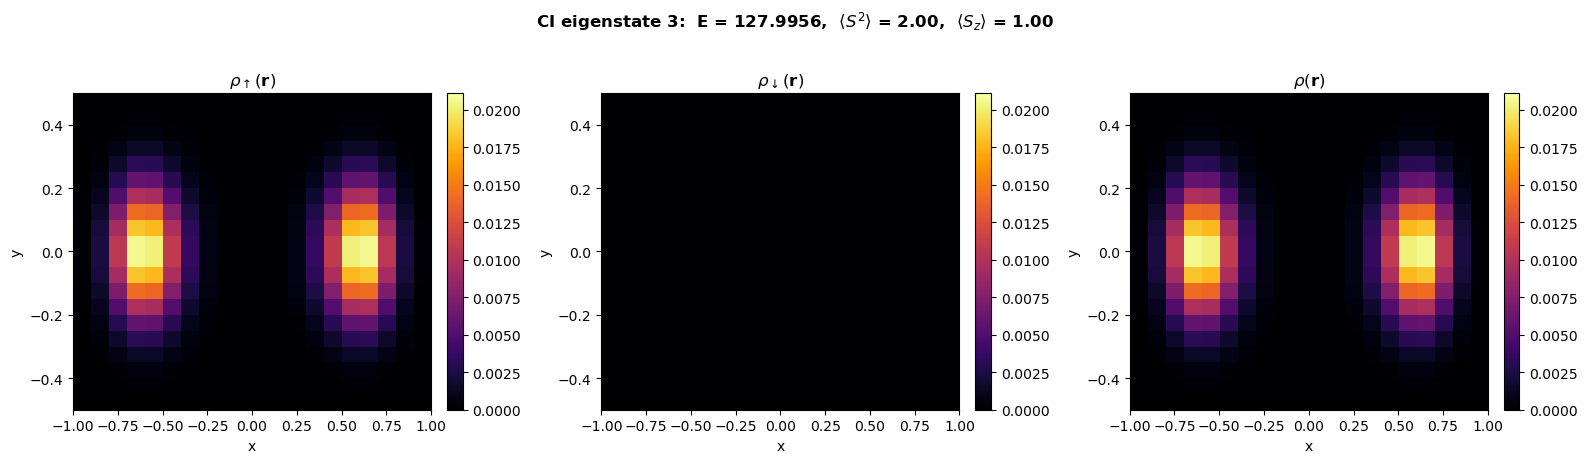


State 10 (spin-resolved):


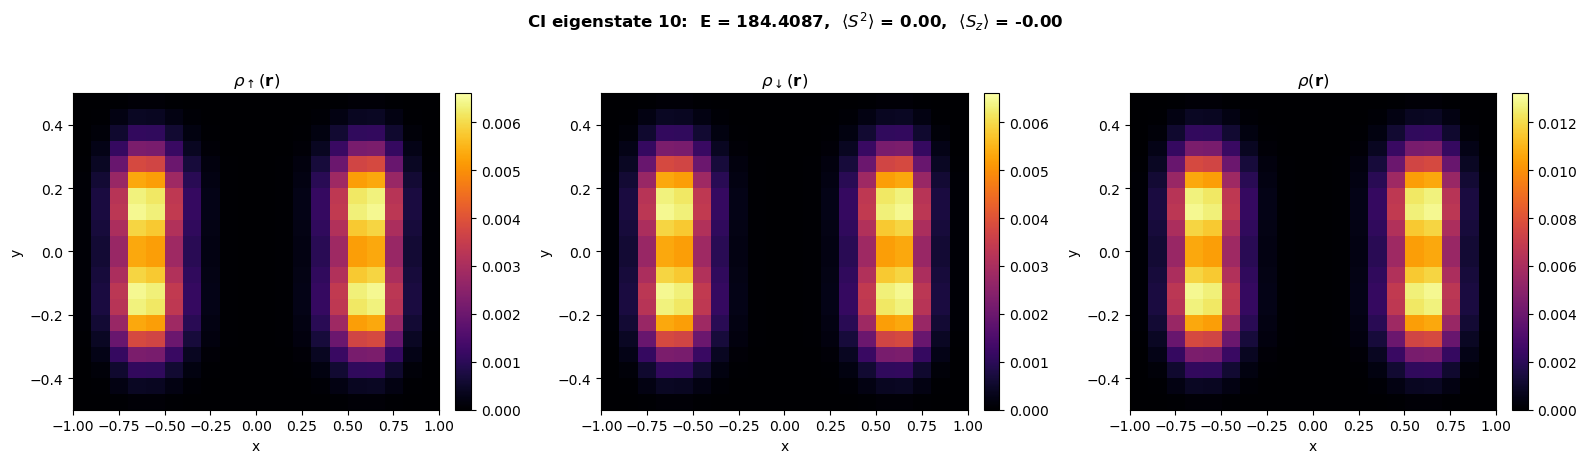

In [28]:
# --- Visualise CI eigenstate densities in real space ---

def plot_ci_density(state_idx, spin_resolved=False, C2_use=None):
    """
    Plot the one-body electron density of CI eigenstate `state_idx`.

    Parameters
    ----------
    state_idx     : int — index into E2/C2 for the eigenstate to visualise
    spin_resolved : bool — if True, show spin-up, spin-down, and total as 3 panels
    C2_use        : optional coefficient matrix; defaults to C2_spin_purified or C2
    """
    if C2_use is None:
        C2_use = globals().get('C2_spin_purified', C2)

    coeffs = C2_use[:, state_idx]

    # Build Ω in delocalized spin-orbital basis and get 1-RDM
    Om = ci_to_spinorbital_Omega(coeffs, slater_basis[:n_compute], Nstates)
    # 1-RDM: γ_{pq} = (Ω Ω†)_{pq}
    gamma = Om @ Om.conj().T

    # Extract spin blocks  (spin-orbital index: 2*a = ↑,  2*a+1 = ↓)
    gamma_up = gamma[0::2, 0::2].real   # (Nstates, Nstates) up-up block
    gamma_dn = gamma[1::2, 1::2].real   # (Nstates, Nstates) dn-dn block

    # Spatial wave functions at each grid point: single_vecs is (Ngrid, Nstates)
    V = single_vecs[:, :Nstates]

    # ρ_σ(r) = Σ_{ab} γ^σ_{ab} ψ_a(r) ψ*_b(r)
    rho_up = np.sum((V @ gamma_up) * V, axis=1).real
    rho_dn = np.sum((V @ gamma_dn) * V, axis=1).real
    rho_tot = rho_up + rho_dn

    # Spin expectation and energy for the title
    S2, Sz, _ = compute_spin_and_entanglement(coeffs, slater_basis[:n_compute], Nstates)

    if spin_resolved:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        panels = [
            (rho_up,  r'$\rho_\uparrow(\mathbf{r})$'),
            (rho_dn,  r'$\rho_\downarrow(\mathbf{r})$'),
            (rho_tot, r'$\rho(\mathbf{r})$'),
        ]
        vmax = max(rho_up.max(), rho_dn.max()) * 1.02
        for ax, (rho, label) in zip(axes, panels):
            Z = rho.reshape(Nx, Ny)
            im = ax.imshow(Z.T, origin='lower', extent=(x0, xL, y0, yL),
                           aspect='auto', cmap='inferno',
                           vmin=0, vmax=vmax if 'uparrow' in label or 'downarrow' in label else rho_tot.max() * 1.02)
            ax.set(xlabel='x', ylabel='y', title=label)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        fig, ax = plt.subplots(1, 1, figsize=(7, 5))
        Z = rho_tot.reshape(Nx, Ny)
        im = ax.imshow(Z.T, origin='lower', extent=(x0, xL, y0, yL),
                       aspect='auto', cmap='inferno')
        ax.set(xlabel='x', ylabel='y', title=r'$\rho(\mathbf{r})$')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(
        f'CI eigenstate {state_idx}:  '
        f'E = {E2[state_idx]:.4f},  '
        rf'$\langle S^2\rangle$ = {S2:.2f},  '
        rf'$\langle S_z\rangle$ = {Sz:.2f}',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()


# --- Quick demo: ground state and first excited state ---
print("\nState 3 (spin-resolved):")
plot_ci_density(3, spin_resolved=True)

print("\nState 10 (spin-resolved):")
plot_ci_density(10, spin_resolved=True)

### Outputs

In [29]:
print("Left-well entanglement in localised basis (with spin):")
print(f"{'#':>3}  {'E2':>10}  {'<S2>':>6}  {'<Sz>':>6}  {'S(rhoL)':>10}  {'E_acc':>10}  {'p0':>7}  {'p1':>7}  {'p2':>7}")

U_spin = spinorbital_U_from_spatial(U_loc)
C2_eval = globals().get('C2_spin_purified', C2)

for n_state in range(min(20, len(E2))):
    # spin moments from CI coefficients in the spin-adapted Slater basis
    S2, Sz, _ = compute_spin_and_entanglement(
        C2_eval[:, n_state], slater_basis[:n_compute], Nstates
    )

    # build Ω in delocalised spin-orbitals, truncate, rotate to localised spin-orbitals
    Om_full = ci_to_spinorbital_Omega(C2_eval[:, n_state], slater_basis[:n_compute], Nstates)
    Om_sub  = truncate_Omega_to_subspace(Om_full, M_LOC)

    # Correct general formula: Ω' = U† Ω Ū = (U*)^T Ω U*
    # U_spin is real here (eigenvectors of real symmetric projector), so U* = U,
    # and this reduces to U^T Ω U.  Using the conjugate form is safe regardless.
    Om_loc  = U_spin.conj().T @ Om_sub @ U_spin.conj()
    Om_loc  = 0.5 * (Om_loc - Om_loc.T)   # enforce exact antisymmetry

    # rho2 in pair basis -> partial trace -> entropies
    rho2_loc, pairs_spin = Omega_to_rho2_pair(Om_loc)
    rhoL0, rhoL1, rhoL2, _ = rhoL_from_rho2_pairs_spin(rho2_loc, pairs_spin, mode_tags_spin)

    S_naive = entropy_blockdiag(rhoL0, rhoL1, rhoL2)
    E_acc, (p0, p1, p2) = accessible_entropy(rhoL0, rhoL1, rhoL2)

    print(f"{n_state:3d}  {E2[n_state]:10.4f}  {S2:6.2f}  {Sz:6.2f}  "
          f"{S_naive:10.5f}  {E_acc:10.5f}  {p0:7.4f}  {p1:7.4f}  {p2:7.4f}")

Left-well entanglement in localised basis (with spin):
  #          E2    <S2>    <Sz>     S(rhoL)       E_acc       p0       p1       p2
  0    127.7779    0.00    0.00     0.72726     0.68933   0.0028   0.9945   0.0028
  1    127.9956    2.00   -1.00     0.00145     0.00000   0.0001   0.9999   0.0001
  2    127.9956    2.00    0.00     0.69450     0.69305   0.0001   0.9999   0.0001
  3    127.9956    2.00    1.00     0.00145     0.00000   0.0001   0.9999   0.0001
  4    128.3346    0.00    0.00     0.69460     0.00019   0.4999   0.0001   0.4999
  5    128.6327    0.00    0.00     0.72727     0.00382   0.4972   0.0055   0.4972
  6    184.3465    2.00   -1.00     1.38629     0.34657   0.2500   0.5000   0.2500
  7    184.3465    2.00   -0.00     1.73287     0.69315   0.2500   0.5000   0.2500
  8    184.3465    2.00    1.00     1.38629     0.34657   0.2500   0.5000   0.2500
  9    184.3928    0.00   -0.00     1.57382     1.30166   0.0305   0.9390   0.0305
 10    184.4087    0.00   -0.00 

---
### State analysis — Left-well energy-level and spin populations (CI eigenstates)
This cell computes, for each CI eigenstate n, the expectation values:
- Left-well spin-resolved populations in each *localised spatial orbital* μ:
    n_{L,μ,↑} = ⟨ n_{μ↑} ⟩,   n_{L,μ,↓} = ⟨ n_{μ↓} ⟩   for μ tagged 'L'
- Left-well orbital population:
    n_{L,μ} = n_{L,μ,↑} + n_{L,μ,↓}
- Left-well spin polarisation per orbital:
    s_{L,μ} = n_{L,μ,↑} − n_{L,μ,↓}
We do this by:
1) building the 1-RDM γ in the delocalised spin-orbital basis from Ω,
2) rotating it into the localised spin-orbital basis with U_spin,
3) reading off diagonal elements γ'_{p,p} = ⟨n_p⟩.
The output table reports totals on the left well and the first few left orbitals.


In [30]:

def _gamma1_from_Omega_correct(Om):
    """
    For a pure 2-fermion state |Psi> = sum_{p<q} A_{pq} c_p^† c_q^† |0>,
    with A normalized so sum_{p<q} |A_{pq}|^2 = 1,
    the 1-RDM is: gamma = 2 * A A^†.

    In your code Om plays the role of A embedded as an antisymmetric matrix
    (Om[p,q]=A_{pq} for p<q, Om[q,p]=-A_{pq}).
    Then A A^† = Om Om^†, so gamma = 2 * Om Om^†.
    """
    return 2.0 * (Om @ Om.conj().T)

def _build_Uspin_from_Uloc(U_loc, M_LOC):
    U = np.asarray(U_loc[:M_LOC, :M_LOC], dtype=complex)
    d = 2 * M_LOC
    U_spin = np.zeros((d, d), dtype=complex)
    for a in range(M_LOC):
        for mu in range(M_LOC):
            U_spin[2*a,   2*mu]   = U[a, mu]
            U_spin[2*a+1, 2*mu+1] = U[a, mu]
    return U_spin

def left_well_level_spin_populations_ci(coeffs_ci, slater_basis, Nstates,
                                        U_loc, lr_labels, M_LOC,
                                        mu_show=6, tol=1e-12):
    """
    Compute populations per localised /left/ level and spin from the CI state.

    Returns:
      per_mu : list of tuples (mu, n_up, n_dn, n_tot, s_z) for mu in left set
      totals : dict with nL, nL_up, nL_dn, Sz_L
    """
    # Build Omega in delocalised spin-orbitals (2*Nstates)
    Om_full = ci_to_spinorbital_Omega(coeffs_ci, slater_basis, Nstates)

    # Truncate to localisation subspace (2*M_LOC)
    dsub = 2 * M_LOC
    Om_sub = Om_full[:dsub, :dsub]

    # 1-RDM in delocalised basis, properly normalised (Tr=2)
    gamma = _gamma1_from_Omega_correct(Om_sub)

    # Rotate gamma into localised spin-orbital basis
    U_spin = _build_Uspin_from_Uloc(U_loc, M_LOC)
    gamma_loc = U_spin.conj().T @ gamma @ U_spin
    occ_so = np.real(np.diag(gamma_loc))  # <n_p>, should be in [0,1]

    # Reshape into spatial mu,spin
    n_up = occ_so[0::2]
    n_dn = occ_so[1::2]

    left_mu = [mu for mu in range(M_LOC) if lr_labels[mu] == 'L']
    per_mu = []
    for mu in left_mu:
        nu = float(n_up[mu])
        nd = float(n_dn[mu])
        per_mu.append((mu, nu, nd, nu + nd, 0.5 * (nu - nd)))

    nL_up = float(np.sum(n_up[left_mu]))
    nL_dn = float(np.sum(n_dn[left_mu]))
    totals = dict(
        nL=nL_up + nL_dn,
        nL_up=nL_up,
        nL_dn=nL_dn,
        Sz_L=0.5 * (nL_up - nL_dn),
        left_mu=left_mu
    )

    return per_mu, totals

In [31]:
print("Left-well populations per localised level and spin (from 1-RDM):")
print(f"{'#':>3}  {'E2':>10}  {'<S2>':>6}  {'<Sz>':>6}  {'nL':>7}  {'Sz_L':>8}  |  first left levels: Lmu(n_up,n_dn)")

C2_eval = globals().get('C2_spin_purified', C2)

for n_state in range(min(20, len(E2))):
    coeffs = C2_eval[:, n_state]
    S2, Sz, _ = compute_spin_and_entanglement(coeffs, slater_basis[:n_compute], Nstates)

    per_mu, tot = left_well_level_spin_populations_ci(
        coeffs, slater_basis[:n_compute], Nstates,
        U_loc, lr_labels, M_LOC
    )

    # show first few left levels
    show = per_mu[:20]
    show_str = "  ".join([f"L{mu}:{nu:.3f},{nd:.3f}" for (mu,nu,nd,_,_) in show])

    print(f"{n_state:3d}  {E2[n_state]:10.4f}  {S2:6.2f}  {Sz:6.2f}  "
          f"{tot['nL']:7.4f}  {tot['Sz_L']:8.4f}  |  {show_str}")

Left-well populations per localised level and spin (from 1-RDM):
  #          E2    <S2>    <Sz>       nL      Sz_L  |  first left levels: Lmu(n_up,n_dn)
  0    127.7779    0.00    0.00   1.0000   -0.0000  |  L0:0.427,0.427  L1:0.000,0.000  L2:0.067,0.067  L3:0.000,0.000  L4:0.000,0.000  L5:0.000,0.000  L6:0.005,0.005  L7:0.000,0.000  L8:0.000,0.000  L9:0.000,0.000  L10:0.001,0.001  L11:0.000,0.000  L12:0.000,0.000  L13:0.000,0.000  L14:0.000,0.000
  1    127.9956    2.00   -1.00   1.0000   -0.5000  |  L0:0.000,0.854  L1:0.000,0.000  L2:0.000,0.135  L3:0.000,0.000  L4:0.000,0.000  L5:0.000,0.000  L6:0.000,0.010  L7:0.000,0.000  L8:0.000,0.000  L9:0.000,0.000  L10:0.000,0.001  L11:0.000,0.000  L12:0.000,0.000  L13:0.000,0.000  L14:0.000,0.000
  2    127.9956    2.00    0.00   1.0000    0.0000  |  L0:0.427,0.427  L1:0.000,0.000  L2:0.067,0.067  L3:0.000,0.000  L4:0.000,0.000  L5:0.000,0.000  L6:0.005,0.005  L7:0.000,0.000  L8:0.000,0.000  L9:0.000,0.000  L10:0.001,0.001  L11:0.000,0.000 

In [179]:
def double_occupancy_from_rho2_pair(rho2, pairs, lr_labels, M_LOC, side='L'):
    pair_index = {(p, q): i for i, (p, q) in enumerate(pairs)}
    D_list = []
    for μ in range(M_LOC):
        if lr_labels[μ] != side:
            continue
        p = 2*μ
        q = 2*μ + 1
        I = pair_index[(p, q)]  # p<q always here
        Dμ = float(np.real(rho2[I, I]))
        D_list.append((μ, Dμ))
    D_tot = float(sum(D for _, D in D_list))
    return D_list, D_tot

In [180]:
print("Left-well double occupancy from rho2 diagonal:")
print(f"{'#':>3}  {'E2':>10}  {'<S2>':>6}  {'<Sz>':>6}  {'D_L':>8}  |  first left levels: Lmu:Dmu")

C2_eval = globals().get('C2_spin_purified', C2)
U_spin = spinorbital_U_from_spatial(U_loc)

for n_state in range(min(20, len(E2))):
    coeffs = C2_eval[:, n_state]
    S2, Sz, _ = compute_spin_and_entanglement(coeffs, slater_basis[:n_compute], Nstates)

    Om_full = ci_to_spinorbital_Omega(coeffs, slater_basis[:n_compute], Nstates)
    Om_sub  = truncate_Omega_to_subspace(Om_full, M_LOC)
    Om_loc  = U_spin.conj().T @ Om_sub @ U_spin.conj()
    Om_loc  = 0.5*(Om_loc - Om_loc.T)

    rho2_loc, pairs = Omega_to_rho2_pair(Om_loc)

    D_list, D_tot = double_occupancy_from_rho2_pair(rho2_loc, pairs, lr_labels, M_LOC, side='L')
    show = D_list[:6]
    show_str = "  ".join([f"L{mu}:{D:.4f}" for mu, D in show])

    print(f"{n_state:3d}  {E2[n_state]:10.4f}  {S2:6.2f}  {Sz:6.2f}  {D_tot:8.5f}  |  {show_str}")

Left-well double occupancy from rho2 diagonal:
  #          E2    <S2>    <Sz>       D_L  |  first left levels: Lmu:Dmu
  0    127.7779    0.00    0.00   0.00192  |  L0:0.0019  L1:0.0000  L2:0.0001  L3:0.0000  L4:0.0000  L5:0.0000
  1    127.9956    2.00   -1.00   0.00000  |  L0:0.0000  L1:0.0000  L2:0.0000  L3:0.0000  L4:0.0000  L5:0.0000
  2    127.9956    2.00   -0.00   0.00000  |  L0:0.0000  L1:0.0000  L2:0.0000  L3:0.0000  L4:0.0000  L5:0.0000
  3    127.9956    2.00    1.00   0.00000  |  L0:0.0000  L1:0.0000  L2:0.0000  L3:0.0000  L4:0.0000  L5:0.0000
  4    128.3346    0.00    0.00   0.37315  |  L0:0.3641  L1:0.0000  L2:0.0090  L3:0.0000  L4:0.0000  L5:0.0000
  5    128.6327    0.00    0.00   0.37075  |  L0:0.3620  L1:0.0000  L2:0.0087  L3:0.0000  L4:0.0000  L5:0.0000
  6    184.3465    2.00   -1.00   0.00000  |  L0:0.0000  L1:0.0000  L2:0.0000  L3:0.0000  L4:0.0000  L5:0.0000
  7    184.3465    2.00   -0.00   0.00000  |  L0:0.0000  L1:0.0000  L2:0.0000  L3:0.0000  L4:0.0000  L5

 ---
 #### Top terms of ρ_L^(1) and ρ_L^(2) for a chosen CI state

 Prints the largest |element| entries of:
 - $ρ_L^{(1)}$: basis = left spin-orbitals $|μ,σ⟩$
 - $ρ_L^{(2)}$: basis = left two-electron states $|p,q⟩$ with $p<q$ (antisymmetrised pairs)

 You can interpret the output as:
  - $ρ_L^{(1)} ≈ \sum a_{ij} |i⟩⟨j|$ 
  - $ρ_L^{(2)} ≈ \sum b_{IJ} |I⟩⟨J|$ 
  
 where the reported terms are those with largest $|a_{ij}|$ and $|b_{IJ}|$.

In [181]:
def ket_spinorb(p):
    mu = p // 2
    sp = "↑" if (p % 2 == 0) else "↓"
    side = lr_labels[mu]
    return f"|{side}{mu}{sp}⟩"

def bra_spinorb(p):
    mu = p // 2
    sp = "↑" if (p % 2 == 0) else "↓"
    side = lr_labels[mu]
    return f"⟨{side}{mu}{sp}|"

def ket_pair(p, q):
    return f"|{lr_labels[p//2]}{p//2}{'↑' if p%2==0 else '↓'}, {lr_labels[q//2]}{q//2}{'↑' if q%2==0 else '↓'}⟩"

def bra_pair(p, q):
    return f"⟨{lr_labels[p//2]}{p//2}{'↑' if p%2==0 else '↓'}, {lr_labels[q//2]}{q//2}{'↑' if q%2==0 else '↓'}|"

def top_elements(mat, k=5, hermitian=True, tol=1e-14):
    mat = np.asarray(mat)
    n, m = mat.shape
    out = []
    for i in range(n):
        j0 = i if hermitian else 0
        for j in range(j0, m):
            val = mat[i, j]
            if abs(val) < tol:
                continue
            out.append((abs(val), val, i, j))
    out.sort(key=lambda x: x[0], reverse=True)
    return out[:k]

def compute_left_blocks_for_state(state_idx=0, C2_use=None):
    """
    Returns (rhoL0, rhoL1, rhoL2, meta) for CI eigenstate `state_idx`,
    in the localised L/R basis with spin, using the N=2 sector partial trace.
    """
    if C2_use is None:
        C2_use = globals().get('C2_spin_purified', C2)

    # CI coefficients in spin-adapted slater basis
    coeffs = C2_use[:, state_idx]

    # Ω in delocalised spin-orbital basis (2*Nstates), then truncate to 2*M_LOC
    Om_full = ci_to_spinorbital_Omega(coeffs, slater_basis[:n_compute], Nstates)
    Om_sub  = truncate_Omega_to_subspace(Om_full, M_LOC)

    # rotate Ω to localised spin-orbitals
    U_spin = spinorbital_U_from_spatial(U_loc)  # (2*M_LOC, 2*M_LOC)
    Om_loc = U_spin.conj().T @ Om_sub @ U_spin.conj()
    Om_loc = 0.5 * (Om_loc - Om_loc.T)          # enforce antisymmetry

    # build rho2 in pair basis
    rho2_loc, pairs = Omega_to_rho2_pair(Om_loc)

    # build mode tags if not already present
    global mode_tags_spin
    if 'mode_tags_spin' not in globals():
        mode_tags_spin = []
        for mu in range(M_LOC):
            mode_tags_spin.append(lr_labels[mu])
            mode_tags_spin.append(lr_labels[mu])

    # partial trace over right modes -> left blocks
    rhoL0, rhoL1, rhoL2, meta = rhoL_from_rho2_pairs_spin(rho2_loc, pairs, mode_tags_spin)
    return rhoL0, rhoL1, rhoL2, meta

def report_top_terms_rhoL_pretty(state_idx=0, k1=5, k2=5, conditional=False):
    rhoL0, rhoL1, rhoL2, meta = compute_left_blocks_for_state(state_idx)
    p0 = float(np.real(rhoL0))
    p1 = float(np.real(np.trace(rhoL1)))
    p2 = float(np.real(np.trace(rhoL2)))

    if conditional:
        if p1 > 1e-14: rhoL1 = rhoL1 / p1
        if p2 > 1e-14: rhoL2 = rhoL2 / p2

    L_modes = meta["L_modes"]
    LL_pairs = meta["LL_pairs"]

    t1 = top_elements(rhoL1, k=k1, hermitian=True)
    t2 = top_elements(rhoL2, k=k2, hermitian=True)

    tag = " (conditional blocks)" if conditional else ""
    print(f"State {state_idx}: E2={E2[state_idx]:.6f}   p(NL=0,1,2)=({p0:.4g},{p1:.4g},{p2:.4g}){tag}\n")

    print(f"ρ_L^(1) top {k1} terms:")
    for _, val, i, j in t1:
        pi = L_modes[i]
        pj = L_modes[j]
        op = f"{ket_spinorb(pi)}{bra_spinorb(pj)}"
        print(f"  {val.real:+.3e}{val.imag:+.3e}i   {op}")

    print(f"\nρ_L^(2) top {k2} terms:")
    for _, val, i, j in t2:
        (p,q) = LL_pairs[i]
        (r,s) = LL_pairs[j]
        op = f"{ket_pair(p,q)}{bra_pair(r,s)}"
        print(f"  {val.real:+.3e}{val.imag:+.3e}i   {op}")

# example
report_top_terms_rhoL_pretty(state_idx=0, k1=5, k2=5, conditional=False)

State 0: E2=127.777916   p(NL=0,1,2)=(0.002751,0.9945,0.002751)

ρ_L^(1) top 5 terms:
  +4.246e-01+0.000e+00i   |L0↑⟩⟨L0↑|
  +4.246e-01+0.000e+00i   |L0↓⟩⟨L0↓|
  -1.688e-01+0.000e+00i   |L0↑⟩⟨L2↑|
  -1.688e-01+0.000e+00i   |L0↓⟩⟨L2↓|
  +6.708e-02+0.000e+00i   |L2↑⟩⟨L2↑|

ρ_L^(2) top 5 terms:
  +1.867e-03+0.000e+00i   |L0↑, L0↓⟩⟨L0↑, L0↓|
  -7.752e-04-0.000e+00i   |L0↑, L0↓⟩⟨L0↑, L2↓|
  +7.752e-04+0.000e+00i   |L0↑, L0↓⟩⟨L0↓, L2↑|
  +3.219e-04+0.000e+00i   |L0↑, L2↓⟩⟨L0↑, L2↓|
  -3.219e-04+0.000e+00i   |L0↑, L2↓⟩⟨L0↓, L2↑|


---
The operator
|L0↑, L0↓⟩⟨L0↑, L2↓|
is an “outer product” that maps the basis state |L0↑, L2↓⟩ into |L0↑, L0↓⟩.

Interpretation of the coefficient:
- If this coefficient is nonzero, it means there is *coherence (a superposition phase relationship)* in the reduced left state between:
  - “both electrons in L0 (↑↓)” and
  - “one electron in L0↑ and one in L2↓”
within the N_L=2 sector.

Where does such a coherence come from physically?
- It comes from the full two-electron state having components like
  α |(L0↑,L0↓) on L ; (vacuum) on R⟩  +  β |(L0↑,L2↓) on L ; (vacuum) on R⟩
and, crucially, these components share the same right-well configuration (R vacuum), so they survive the partial trace and appear as off-diagonals in ρ_L^(2).

---
## Section 8 — Quantum Sensing via Left-Well Spin Readout

We now couple the magnetic field only to the **spin density in the left well**,

$$H_{\mathrm{pert}}(t)=\frac{g\mu_B}{2}\,B(t)\,\Sigma_{z,L},
\qquad
\Sigma_{z,L}=\sum_{\mu\in L}\left(n_{\mu\uparrow}-n_{\mu\downarrow}\right).$$

Because the perturbation is defined in the **localised** L/R basis, it must be
rotated back into the current **energy-sorted CI basis** before propagation.

**Protocol:**
1. Identify the most entangled $(1,1)$-like singlet using the localised-basis quantities from Section 7.
2. Build $\Sigma_{z,L}$ in the localised spin-orbital basis and map it into the CI basis.
3. Evolve exactly under $H(t)=H_0+B(t)\Sigma_{z,L}$.
4. Monitor singlet / triplet-$T_0$ transfer, accumulated phase, and the QFI.

In [182]:
# --- Section 8 helper functions adapted to the current spin-adapted CI basis ---
from scipy.linalg import expm

C2_eval = globals().get('C2_spin_purified', C2)
n_ci = min(n_compute, C2_eval.shape[0], C2_eval.shape[1], len(E2), len(slater_basis))
basis_ci = C2_eval[:n_ci, :n_ci].copy()  # columns = CI eigenstates in the truncated Slater basis
ambiguous_spin_orbs = [2 * mu + s for mu in ambiguous_mu for s in (0, 1)]


def _spin_adapted_components(entry):
    """Return determinant components (amp, (p, q)) for one spin-adapted basis state."""
    a, b, _, stype = entry
    ia_up, ia_dn = 2 * a, 2 * a + 1
    ib_up, ib_dn = 2 * b, 2 * b + 1

    if a == b:
        return [(1.0 / np.sqrt(2.0), (ia_up, ia_dn))]
    if stype == 'singlet':
        return [
            (0.5, (ia_up, ib_dn)),
            (-0.5, (ia_dn, ib_up)),
        ]
    if stype == 'triplet_p':
        return [(1.0 / np.sqrt(2.0), (ia_up, ib_up))]
    if stype == 'triplet_0':
        return [
            (0.5, (ia_up, ib_dn)),
            (0.5, (ia_dn, ib_up)),
        ]
    if stype == 'triplet_m':
        return [(1.0 / np.sqrt(2.0), (ia_dn, ib_dn))]
    raise ValueError(f'Unknown spin type: {stype}')


_def_det_tol = 1e-14


def _one_body_det_me(A, bra_occ, ket_occ):
    """Matrix element <bra| sum_pq A[p,q] c_p^dagger c_q |ket> for 2-electron determinants."""
    val = 0.0j
    ket_occ = tuple(ket_occ)
    bra_occ = tuple(bra_occ)

    for q_idx, q in enumerate(ket_occ):
        sign_q = -1 if q_idx % 2 else 1
        occ_after_ann = ket_occ[:q_idx] + ket_occ[q_idx + 1:]
        for p in range(A.shape[0]):
            amp = A[p, q]
            if abs(amp) < _def_det_tol or p in occ_after_ann:
                continue
            insert_idx = sum(occ < p for occ in occ_after_ann)
            sign_p = -1 if insert_idx % 2 else 1
            new_occ = occ_after_ann[:insert_idx] + (p,) + occ_after_ann[insert_idx:]
            if new_occ == bra_occ:
                val += sign_p * sign_q * amp
    return val


# 1) Build sigma_z on the left well in the delocalized spin-orbital basis

def build_sigma_z_left_spinorbital(U_loc, lr_labels, Nstates):
    """Return Sigma_z,L in the delocalized spin-orbital basis of size 2*Nstates."""
    M_loc = U_loc.shape[0]
    d_loc = 2 * M_loc
    sigma_loc = np.zeros((d_loc, d_loc), dtype=complex)

    for mu in range(M_loc):
        if lr_labels[mu] != 'L':
            continue
        sigma_loc[2 * mu, 2 * mu] = 1.0
        sigma_loc[2 * mu + 1, 2 * mu + 1] = -1.0

    U_spin_loc = spinorbital_U_from_spatial(U_loc)
    sigma_sub = U_spin_loc @ sigma_loc @ U_spin_loc.conj().T

    sigma_full = np.zeros((2 * Nstates, 2 * Nstates), dtype=complex)
    sigma_full[:d_loc, :d_loc] = sigma_sub
    return 0.5 * (sigma_full + sigma_full.conj().T)


# 2) Project a one-body spin-orbital operator into the current CI eigenbasis

def build_onebody_operator_ci(A_spinorb, basis_ci, Nstates):
    """Project a one-body spin-orbital operator into the truncated CI eigenbasis."""
    n_slater, n_eig = basis_ci.shape
    O_slater = np.zeros((n_slater, n_slater), dtype=complex)

    components = [_spin_adapted_components(slater_basis[j]) for j in range(n_slater)]
    for i in range(n_slater):
        bra_comps = components[i]
        for j in range(n_slater):
            ket_comps = components[j]
            val = 0.0j
            for amp_bra, bra_occ in bra_comps:
                for amp_ket, ket_occ in ket_comps:
                    val += np.conj(amp_bra) * amp_ket * _one_body_det_me(A_spinorb, bra_occ, ket_occ)
            O_slater[i, j] = val

    basis_amps = basis_ci.copy()
    O_ci = basis_amps.conj().T @ O_slater @ basis_amps
    return 0.5 * (O_ci + O_ci.conj().T), basis_amps


# 3) Localized-basis L/R diagnostics for one CI eigenstate

def localised_lr_metrics(state_idx):
    coeffs = basis_ci[:, state_idx]
    U_spin_eval = globals().get('U_spin', spinorbital_U_from_spatial(U_loc))

    S2, Sz, _ = compute_spin_and_entanglement(coeffs, slater_basis[:n_ci], Nstates)
    Om_full = ci_to_spinorbital_Omega(coeffs, slater_basis[:n_ci], Nstates)
    Om_sub = truncate_Omega_to_subspace(Om_full, M_LOC)
    Om_loc = U_spin_eval.conj().T @ Om_sub @ U_spin_eval.conj()
    Om_loc = 0.5 * (Om_loc - Om_loc.T)

    rho2_loc, pairs_spin = Omega_to_rho2_pair(Om_loc)
    rhoL0, rhoL1, rhoL2, _ = rhoL_from_rho2_pairs_spin(rho2_loc, pairs_spin, mode_tags_spin)
    S_lr = entropy_blockdiag(rhoL0, rhoL1, rhoL2)
    E_acc, (p0, p1, p2) = accessible_entropy(rhoL0, rhoL1, rhoL2)

    return {
        'S2': float(S2),
        'Sz': float(Sz),
        'S_lr': float(S_lr),
        'E_acc': float(E_acc),
        'p0': float(p0),
        'p1': float(p1),
        'p2': float(p2),
    }


# 4) Dominant localized L/R orbital pair label for one eigenstate

def dominant_lr_config(state_idx):
    coeffs = basis_ci[:, state_idx]
    U_spin_eval = globals().get('U_spin', spinorbital_U_from_spatial(U_loc))

    Om_full = ci_to_spinorbital_Omega(coeffs, slater_basis[:n_ci], Nstates)
    Om_sub = truncate_Omega_to_subspace(Om_full, M_LOC)
    Om_loc = U_spin_eval.conj().T @ Om_sub @ U_spin_eval.conj()
    Om_loc = 0.5 * (Om_loc - Om_loc.T)

    best_weight = -1.0
    best_pair = None
    for p in range(Om_loc.shape[0]):
        for q in range(p + 1, Om_loc.shape[1]):
            weight = float(abs(Om_loc[p, q]) ** 2)
            if weight > best_weight:
                best_weight = weight
                best_pair = (p, q)

    if best_pair is None:
        return 'none', 0.0

    p, q = best_pair
    mu_p, mu_q = p // 2, q // 2
    tag_p, tag_q = mode_tags_spin[p], mode_tags_spin[q]

    if tag_p == 'L' and tag_q == 'R':
        label = f'L{mu_p}-R{mu_q}'
    elif tag_p == 'R' and tag_q == 'L':
        label = f'L{mu_q}-R{mu_p}'
    else:
        label = f'{tag_p}{mu_p}-{tag_q}{mu_q}'
    return label, best_weight


# 5) Exact time evolution under H(t) = H0 + B(t) * Sigma_z,L in the CI eigenbasis

def time_evolve_exact_left(initial_idx, sigma_z_left, B_field, t_array):
    """Exact propagation in the truncated CI eigenbasis."""
    n_ci_loc = sigma_z_left.shape[0]
    if initial_idx >= n_ci_loc:
        raise IndexError(f'initial_idx={initial_idx} outside truncated CI basis of size {n_ci_loc}')

    H0 = np.diag(np.asarray(E2[:n_ci_loc], dtype=float))
    eigvecs = basis_ci[:, :n_ci_loc]

    psi = np.zeros(n_ci_loc, dtype=complex)
    psi[initial_idx] = 1.0

    P_S = np.zeros(len(t_array))
    P_T0 = np.zeros(len(t_array))
    P_Tpm = np.zeros(len(t_array))
    phase_t = np.zeros(len(t_array))
    psi_hist = np.zeros((n_ci_loc, len(t_array)), dtype=complex)

    singlet_mask = np.array([slater_basis[j][3] == 'singlet' for j in range(n_ci)])
    triplet0_mask = np.array([slater_basis[j][3] == 'triplet_0' for j in range(n_ci)])
    tripletpm_mask = np.array([slater_basis[j][3] in ('triplet_p', 'triplet_m') for j in range(n_ci)])

    phase = 0.0
    for k, t in enumerate(t_array):
        psi_hist[:, k] = psi
        phase_t[k] = phase

        coeffs_slater = eigvecs @ psi
        probs_slater = np.abs(coeffs_slater) ** 2
        P_S[k] = float(np.sum(probs_slater[singlet_mask]))
        P_T0[k] = float(np.sum(probs_slater[triplet0_mask]))
        P_Tpm[k] = float(np.sum(probs_slater[tripletpm_mask]))

        if k < len(t_array) - 1:
            dt = t_array[k + 1] - t
            B_mid = B_field(t + 0.5 * dt)
            phase += B_mid * dt
            U_dt = expm(-1j * (H0 + B_mid * sigma_z_left) * dt)
            psi = U_dt @ psi
            norm = np.linalg.norm(psi)
            if norm > 1e-12:
                psi /= norm

    return P_S, P_T0, P_Tpm, phase_t, psi_hist


# 6) Quantum Fisher information from neighboring phase points

def compute_qfi(psi_hist, phase_array):
    """QFI computed by central differences along the accumulated phase axis."""
    n_t = psi_hist.shape[1]
    QFI = np.zeros(n_t)
    for k in range(1, n_t - 1):
        dphi = phase_array[k + 1] - phase_array[k - 1]
        if abs(dphi) < 1e-12:
            continue
        psi = psi_hist[:, k]
        dpsi = (psi_hist[:, k + 1] - psi_hist[:, k - 1]) / dphi
        term1 = np.vdot(dpsi, dpsi).real
        term2 = abs(np.vdot(psi, dpsi)) ** 2
        QFI[k] = 4.0 * max(0.0, term1 - term2)
    if n_t >= 2:
        QFI[0] = QFI[1]
        QFI[-1] = QFI[-2]
    return QFI


# 7) Weight carried by ambiguous localized modes during CI dynamics

def ambiguous_mode_weight_from_psi_ci(psi_ci, ambiguous_spin_orbs):
    """Return total weight with at least one / both electrons in ambiguous modes."""
    coeffs_slater = basis_ci[:, :len(psi_ci)] @ psi_ci
    Om_full = ci_to_spinorbital_Omega(coeffs_slater, slater_basis[:n_ci], Nstates)

    amb = set(ambiguous_spin_orbs)
    w_any = 0.0
    w_both = 0.0
    details = []
    for p in range(Om_full.shape[0]):
        for q in range(p + 1, Om_full.shape[1]):
            weight = float(abs(Om_full[p, q]) ** 2)
            if weight < 1e-14:
                continue
            n_amb = int(p in amb) + int(q in amb)
            if n_amb >= 1:
                w_any += weight
                details.append((p, q, weight, n_amb))
            if n_amb == 2:
                w_both += weight
    return w_any, w_both, details


print('Section 8 helper functions restored.')
print(f'  n_ci = {n_ci}')
print(f'  ambiguous spin-orbitals = {len(ambiguous_spin_orbs)}')

Section 8 helper functions restored.
  n_ci = 200
  ambiguous spin-orbitals = 4


### 8.1 Build the left-well sensing operator

We first construct the operator
$\Sigma_{z,L}=\sum_{\mu\in L}(n_{\mu\uparrow}-n_{\mu\downarrow})$
in the **localised** basis and then project it into the current CI basis.

The quick sanity checks below confirm that the projected operator is Hermitian
and that the basis mapping is numerically stable.

In [183]:
# 1) Build the left-well Zeeman operator in the current CI basis
sigma_z_left_spinorb = build_sigma_z_left_spinorbital(U_loc, lr_labels, Nstates)
sigma_z_left, basis_amps = build_onebody_operator_ci(
    sigma_z_left_spinorb, basis_ci, Nstates
)

basis_overlap_err = np.max(np.abs(basis_amps @ basis_amps.conj().T - np.eye(n_ci)))
print("Left-well sensing operator built:")
print(f"  CI matrix shape          : {sigma_z_left.shape}")
print(f"  Hermitian                : {np.allclose(sigma_z_left, sigma_z_left.conj().T, atol=1e-10)}")
print(f"  Basis orthonormality err : {basis_overlap_err:.2e}")
print(f"  ||Sigma_z,L||_F          : {np.linalg.norm(sigma_z_left):.4f}")

Left-well sensing operator built:
  CI matrix shape          : (200, 200)
  Hermitian                : True
  Basis orthonormality err : 8.92e-14
  ||Sigma_z,L||_F          : 6.6995


### 8.2 Choose the sensing state

We now scan the low-lying CI eigenstates and keep the ones that are:
- predominantly **singlet-like**,
- mostly in the **$(1,1)$ charge sector** (`p1` close to 1), and
- strongly entangled across the left/right cut.

Among these, we select the state with the largest SSR-accessible entanglement `E_acc`.

In [184]:
# 2) Find the most entangled (1,1)-like singlet in the updated basis
scan_rows = []
for state_idx in range(min(20, len(E2), n_ci)):
    met = localised_lr_metrics(state_idx)
    cfg, _ = dominant_lr_config(state_idx)
    if met['S2'] < 0.5 and met['p1'] > 0.80:
        scan_rows.append((state_idx, float(E2[state_idx]), met['E_acc'],
                          met['S_lr'], met['p1'], met['Sz'], cfg))

if not scan_rows:
    for state_idx in range(min(20, len(E2), n_ci)):
        met = localised_lr_metrics(state_idx)
        cfg, _ = dominant_lr_config(state_idx)
        if met['S2'] < 0.8 and met['p1'] > 0.50:
            scan_rows.append((state_idx, float(E2[state_idx]), met['E_acc'],
                              met['S_lr'], met['p1'], met['Sz'], cfg))

scan_rows.sort(key=lambda row: (row[2], row[4]), reverse=True)

print("Candidate (1,1)-like singlets ranked by accessible L/R entanglement:")
print(f"{'State':>5}  {'Energy':>10}  {'E_acc':>10}  {'S(rhoL)':>10}  {'p1':>7}  {'<Sz>':>7}  {'Config':>10}")
for row in scan_rows[:8]:
    st, en, eacc, slr, p1, sz, cfg = row
    print(f"{st:5d}  {en:10.4f}  {eacc:10.5f}  {slr:10.5f}  {p1:7.4f}  {sz:7.3f}  {cfg:>10}")

best_idx = scan_rows[0][0]
best_metrics = localised_lr_metrics(best_idx)
best_cfg, _ = dominant_lr_config(best_idx)

print()
print(f"Selected sensing state: {best_idx}  ({best_cfg})")
print(f"  E_acc = {best_metrics['E_acc']:.6f},   S(rhoL) = {best_metrics['S_lr']:.6f}")
print(f"  p(NL=0,1,2) = ({best_metrics['p0']:.4f}, {best_metrics['p1']:.4f}, {best_metrics['p2']:.4f})")
print(f"  <S^2> = {best_metrics['S2']:.4f},   <Sz> = {best_metrics['Sz']:.4f}")

Candidate (1,1)-like singlets ranked by accessible L/R entanglement:
State      Energy       E_acc     S(rhoL)       p1     <Sz>      Config
   10    184.4087     1.38612     1.38748   0.9999   -0.000      L1-R31
    9    184.3928     1.30166     1.57382   0.9390   -0.000      L1-R31
    0    127.7779     0.68933     0.72726   0.9945    0.000      L0-R31

Selected sensing state: 10  (L1-R31)
  E_acc = 1.386117,   S(rhoL) = 1.387483
  p(NL=0,1,2) = (0.0001, 0.9999, 0.0001)
  <S^2> = 0.0000,   <Sz> = -0.0000


### 8.3 Drive the state with a left-well-only magnetic field

With the sensing state chosen, we evolve it under
$H(t)=H_0 + B(t)\Sigma_{z,L}$ using an exact matrix exponential.

The main observables are the singlet weight, the triplet leakage, and the
accumulated phase $\phi(t)=\int_0^t B(t')\,dt'$.

In [ ]:
# 3) Exact time evolution with a left-well-only magnetic drive
B_amplitude = 0.03
omega_field = (127.9956-127.7779)

def B_field(t):
    return B_amplitude * np.sin(omega_field * t)

best_idx = 0 #Just to check
t_max = 10*np.pi/omega_field
n_time_points = 360
t_array = np.linspace(0.0, t_max, n_time_points)
B_values = np.array([B_field(t) for t in t_array])

P_S, P_T0, P_Tpm, phase_t, psi_hist = time_evolve_exact_left(
    best_idx, sigma_z_left, B_field, t_array
)

QFI = compute_qfi(psi_hist, phase_t)
QFI_max = float(np.max(QFI))
QFI_mean = float(np.mean(QFI[QFI > 1e-12])) if np.any(QFI > 1e-12) else 0.0

amb_any_t = np.zeros(len(t_array))
amb_both_t = np.zeros(len(t_array))
for k in range(len(t_array)):
    w_any, w_both, _ = ambiguous_mode_weight_from_psi_ci(
        psi_hist[:, k], ambiguous_spin_orbs
    )
    amb_any_t[k] = w_any
    amb_both_t[k] = w_both
print("State:", best_idx)
print("Dynamics summary:")
print(f"  initial singlet weight   = {P_S[0]:.6f}")
print(f"  max T0 population        = {P_T0.max():.6f}")
print(f"  max T+/T- population     = {P_Tpm.max():.6f}")
print(f"  max accumulated phase    = {np.max(np.abs(phase_t)):.6f}")
print(f"  peak QFI                 = {QFI_max:.6f}")
print(f"  Cramer-Rao bound         >= {1.0 / np.sqrt(max(QFI_max, 1e-12)):.6f}")
print()
print(f"Ambiguous-mode contribution (tol={LAM_AMBIG_TOL:.3f}):")
print(f"  initial weight (any amb mode) = {amb_any_t[0]:.6f}")
print(f"  final weight   (any amb mode) = {amb_any_t[-1]:.6f}")
print(f"  max over time  (any amb mode) = {amb_any_t.max():.6f}")
print(f"  max over time (both electrons in amb modes) = {amb_both_t.max():.6f}")

State: 0
Dynamics summary:
  initial singlet weight   = 1.000000
  max T0 population        = 0.775196
  max T+/T- population     = 0.000000
  max accumulated phase    = 0.275609
  peak QFI                 = 9797110.531250
  Cramer-Rao bound         >= 0.000319

Ambiguous-mode contribution (tol=0.050):
  initial weight (any amb mode) = 0.000000
  final weight   (any amb mode) = 0.000000
  max over time  (any amb mode) = 0.000000
  max over time (both electrons in amb modes) = 0.000000


 ---
 ### 8.4 — QFI with respect to field amplitude B_amplitude (two-run finite difference)

 We estimate ∂|ψ>/∂B0 by running two simulations with B0±δB and using:
   |∂_{B0}ψ(t)> ≈ (|ψ_+(t)> - |ψ_-(t)>)/(2 δB)

 Then the pure-state QFI is:
   F_Q(B0,t) = 4( <∂ψ|∂ψ> - |<ψ|∂ψ>|^2 )

 Here we evaluate it in the *CI eigenbasis* state vector psi(t) returned by time_evolve_exact_left.

QFI wrt amplitude B0 computed from two simulations:
  dB used      = 0.001
  peak QFI_B0  = 5154.310157
  mean QFI_B0  = 1724.068176


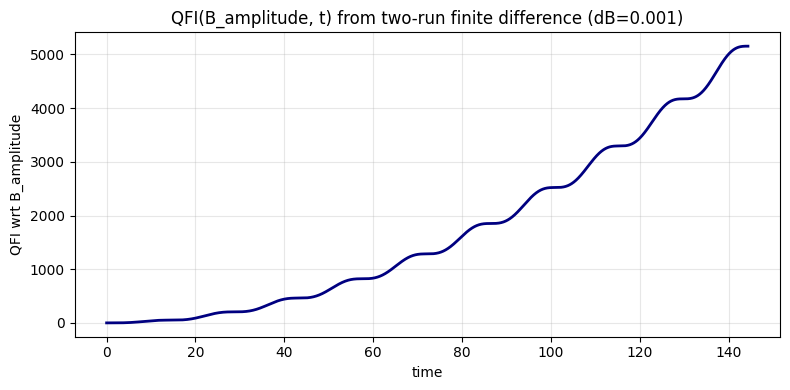

In [186]:
def qfi_from_two_states(psi, dpsi, tol=1e-15):
    """
    Pure-state QFI for parameter lambda using psi and dpsi = ∂_lambda psi.
    """
    # Ensure normalization of psi
    nrm = np.linalg.norm(psi)
    if nrm < tol:
        return 0.0
    psi = psi / nrm

    term1 = np.vdot(dpsi, dpsi).real
    term2 = abs(np.vdot(psi, dpsi))**2
    return float(4.0 * max(0.0, term1 - term2))


# --- choose finite-difference step for amplitude ---
dB = 1e-3  # try 1e-3..1e-2 depending on scales; too small -> numerical noise, too large -> bias

B0 = B_amplitude
omega0 = omega_field

def B_field_plus(t):
    return (B0 + dB) * np.sin(omega0 * t)

def B_field_minus(t):
    return (B0 - dB) * np.sin(omega0 * t)

# Run two simulations (same initial state, same operator sigma_z_left)
P_S_p, P_T0_p, P_Tpm_p, phase_p, psi_hist_p = time_evolve_exact_left(
    best_idx, sigma_z_left, B_field_plus, t_array
)
P_S_m, P_T0_m, P_Tpm_m, phase_m, psi_hist_m = time_evolve_exact_left(
    best_idx, sigma_z_left, B_field_minus, t_array
)

# Compute QFI wrt amplitude B0 at each time
QFI_B0 = np.zeros(len(t_array))
for k in range(len(t_array)):
    psi_c = 0.5 * (psi_hist_p[:, k] + psi_hist_m[:, k])   # central state (optional)
    dpsi  = (psi_hist_p[:, k] - psi_hist_m[:, k]) / (2.0 * dB)
    QFI_B0[k] = qfi_from_two_states(psi_c, dpsi)

QFI_B0_max = float(np.max(QFI_B0))
QFI_B0_mean = float(np.mean(QFI_B0[QFI_B0 > 1e-12])) if np.any(QFI_B0 > 1e-12) else 0.0
print("QFI wrt amplitude B0 computed from two simulations:")
print(f"  dB used      = {dB}")
print(f"  peak QFI_B0  = {float(np.max(QFI_B0)):.6f}")
print(f"  mean QFI_B0  = {float(np.mean(QFI_B0[QFI_B0>1e-12])):.6f}" if np.any(QFI_B0>1e-12) else "  mean QFI_B0  = 0")

# Optional quick plot
plt.figure(figsize=(8,4))
plt.plot(t_array, QFI_B0, lw=2, color='navy')
plt.xlabel("time")
plt.ylabel("QFI wrt B_amplitude")
plt.title(f"QFI(B_amplitude, t) from two-run finite difference (dB={dB})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.5 Visualise the sensing response and metrological gain

The final plots separate the problem into two pieces:
1. the **physical response** of the state (singlet/triplet populations and phase), and
2. the **metrological response** through the QFI and the Cramér–Rao bound.

A larger QFI corresponds to a smaller achievable phase uncertainty.

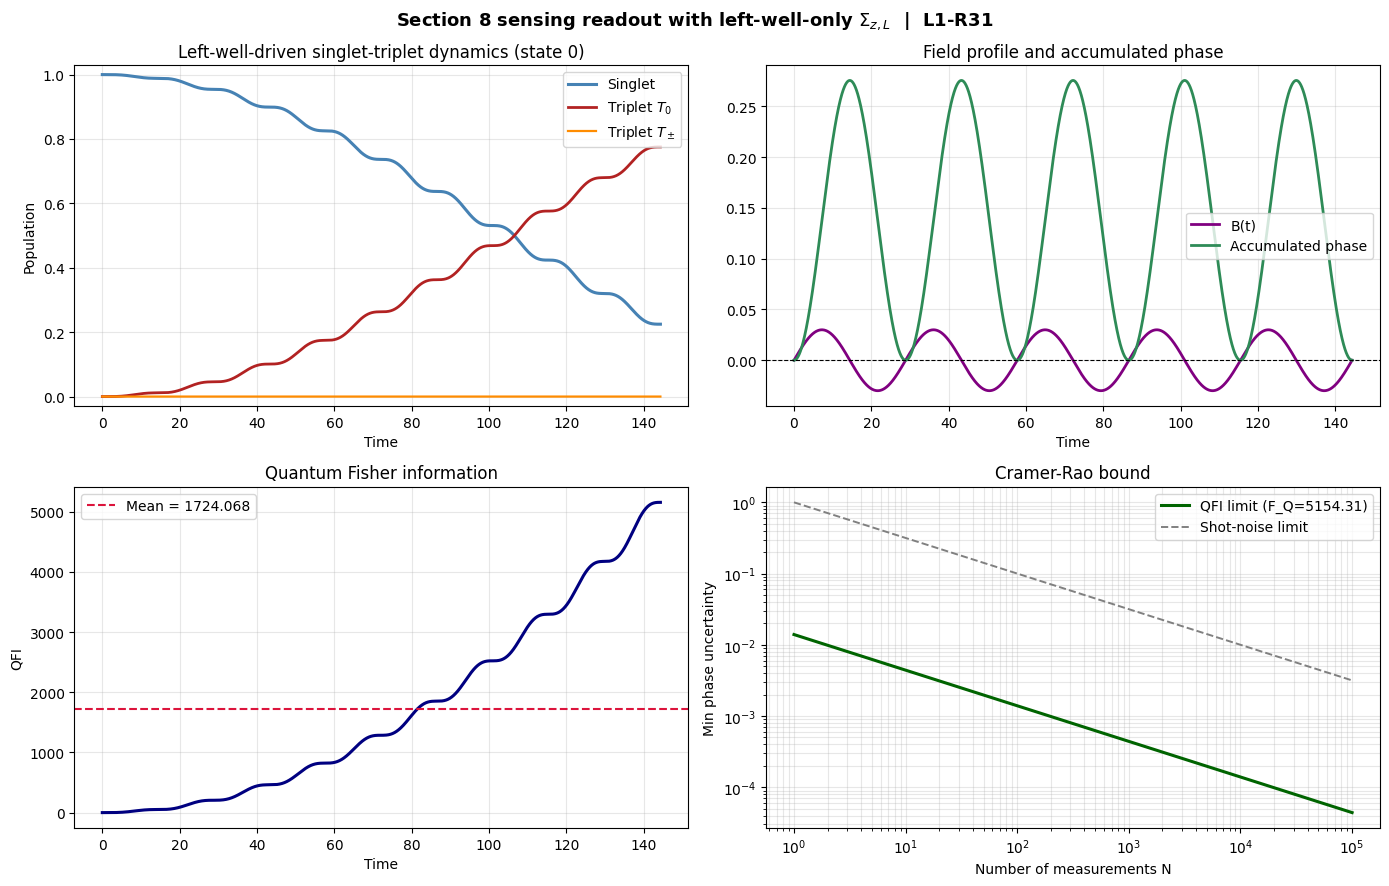

In [187]:
# 4) Visualise the sensing signal and the QFI
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(t_array, P_S,  lw=2.2, color='steelblue',   label='Singlet')
ax.plot(t_array, P_T0, lw=2.0, color='firebrick',   label='Triplet $T_0$')
ax.plot(t_array, P_Tpm, lw=1.6, color='darkorange', label='Triplet $T_\pm$')
ax.set(xlabel='Time', ylabel='Population',
       title=f'Left-well-driven singlet-triplet dynamics (state {best_idx})')
ax.set_ylim(-0.03, 1.03)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax = axes[0, 1]
ax.plot(t_array, B_values, color='purple', lw=2.0, label='B(t)')
ax.plot(t_array, phase_t,  color='seagreen', lw=2.0, label='Accumulated phase')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set(xlabel='Time', title='Field profile and accumulated phase')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax = axes[1, 0]
ax.plot(t_array, QFI_B0, color='navy', lw=2.2)
ax.axhline(QFI_B0_mean, color='crimson', lw=1.5, ls='--', label=f'Mean = {QFI_B0_mean:.3f}')
ax.set(xlabel='Time', ylabel='QFI', title='Quantum Fisher information')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax = axes[1, 1]
N_arr = np.logspace(0, 5, 200)
dphi_qfi = 1.0 / np.sqrt(np.maximum(N_arr * max(QFI_B0_max, 1e-12), 1e-12))
dphi_shot = 1.0 / np.sqrt(N_arr)
ax.loglog(N_arr, dphi_qfi, color='darkgreen', lw=2.2,
          label=f'QFI limit (F_Q={QFI_B0_max:.2f})')
ax.loglog(N_arr, dphi_shot, color='gray', lw=1.4, ls='--', label='Shot-noise limit')
ax.set(xlabel='Number of measurements N', ylabel='Min phase uncertainty',
       title='Cramer-Rao bound')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=10)

plt.suptitle(
    f'Section 8 sensing readout with left-well-only $\\Sigma_{{z,L}}$  |  {best_cfg}',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

 ---
 ### 8.6 Classical Fisher information for S/T readout vs QFI (two-run finite-difference in B0)

 Assumes you already have:
 - best_idx : index of chosen initial CI eigenstate
 - time_evolve_exact_left(...) : returns (P_S, P_T0, P_Tpm, phase, psi_hist)
 - t_array, B_amplitude, omega_field
 - QFI_B0(t) from your two-run QFI cell (or we recompute it here)

 We compute:
 - p_S(t), p_T0(t), p_T±(t) from two runs at B0±dB
 - derivatives dp/dB0 by central differences
 - classical FI for:
     (i) 2-outcome measurement {S, not-S}
     (ii) 3-outcome measurement {S, T0, T±}   (T± grouped)
 - compare to QFI_B0(t)


Peak values:
  max QFI_B0        = 5154.31
  max FI_ST         = 5056.26
  max FI_S_T0_Tpm   = 5056.26
Ratios (how close to QFI):
  max FI_ST / QFI   = 0.9810
  max FI_3 / QFI    = 0.9810


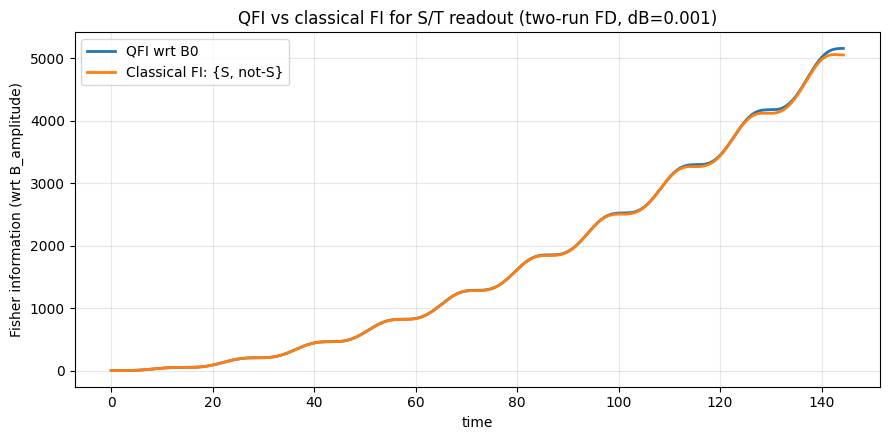

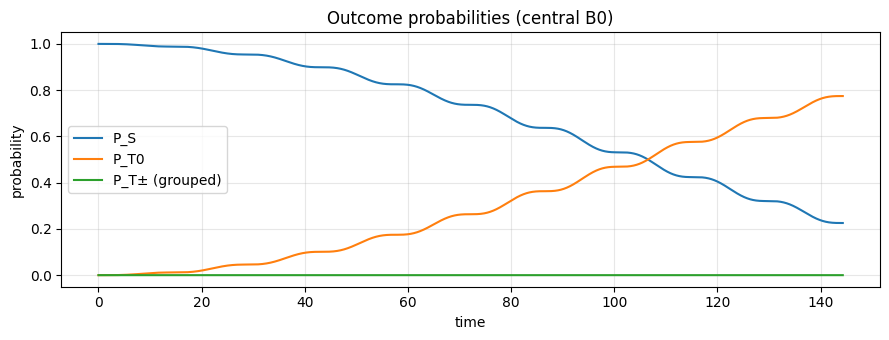

In [188]:
import numpy as np
import matplotlib.pyplot as plt

def qfi_from_two_states(psi, dpsi, tol=1e-15):
    nrm = np.linalg.norm(psi)
    if nrm < tol:
        return 0.0
    psi = psi / nrm
    term1 = np.vdot(dpsi, dpsi).real
    term2 = abs(np.vdot(psi, dpsi))**2
    return float(4.0 * max(0.0, term1 - term2))

def classical_fi_from_probs(p, dp, tol=1e-14):
    """
    p, dp: arrays of shape (n_outcomes,)
    Returns Fisher info sum_i (dp_i^2 / p_i), with safe handling near p_i=0.
    Assumes sum p_i = 1.
    """
    p = np.asarray(p, float)
    dp = np.asarray(dp, float)
    mask = p > tol
    return float(np.sum((dp[mask]**2) / p[mask]))

# --- finite difference step ---
dB = 1e-3
B0 = B_amplitude
omega0 = omega_field

def B_field_plus(t):  return (B0 + dB) * np.sin(omega0 * t)
def B_field_minus(t): return (B0 - dB) * np.sin(omega0 * t)

# --- run two evolutions ---
P_S_p, P_T0_p, P_Tpm_p, phase_p, psi_hist_p = time_evolve_exact_left(
    best_idx, sigma_z_left, B_field_plus, t_array
)
P_S_m, P_T0_m, P_Tpm_m, phase_m, psi_hist_m = time_evolve_exact_left(
    best_idx, sigma_z_left, B_field_minus, t_array
)

# --- central values + derivatives wrt B0 ---
P_S   = 0.5 * (P_S_p   + P_S_m)
P_T0  = 0.5 * (P_T0_p  + P_T0_m)
P_Tpm = 0.5 * (P_Tpm_p + P_Tpm_m)

dP_S   = (P_S_p   - P_S_m)   / (2.0 * dB)
dP_T0  = (P_T0_p  - P_T0_m)  / (2.0 * dB)
dP_Tpm = (P_Tpm_p - P_Tpm_m) / (2.0 * dB)

# --- QFI wrt B0 from the same two runs ---
QFI_B0 = np.zeros_like(t_array, dtype=float)
for k in range(len(t_array)):
    psi_c = 0.5 * (psi_hist_p[:, k] + psi_hist_m[:, k])
    dpsi  = (psi_hist_p[:, k] - psi_hist_m[:, k]) / (2.0 * dB)
    QFI_B0[k] = qfi_from_two_states(psi_c, dpsi)

# --- classical FI for different outcome granularities ---
FI_ST = np.zeros_like(t_array, dtype=float)      # outcomes: {S, not-S}
FI_S_T0_Tpm = np.zeros_like(t_array, dtype=float) # outcomes: {S, T0, Tpm}

for k in range(len(t_array)):
    # 2-outcome: {S, not-S}
    p2 = np.array([P_S[k], 1.0 - P_S[k]])
    dp2 = np.array([dP_S[k], -dP_S[k]])
    FI_ST[k] = classical_fi_from_probs(p2, dp2)

    # 3-outcome: {S, T0, Tpm}
    p3 = np.array([P_S[k], P_T0[k], P_Tpm[k]])
    dp3 = np.array([dP_S[k], dP_T0[k], dP_Tpm[k]])
    # renormalize defensively if tiny numerical drift
    s = p3.sum()
    if abs(s - 1.0) > 1e-10:
        p3 = p3 / s
        dp3 = dp3 - p3 * dp3.sum()  # enforce sum dp = 0
    FI_S_T0_Tpm[k] = classical_fi_from_probs(p3, dp3)

print("Peak values:")
print(f"  max QFI_B0        = {np.max(QFI_B0):.6g}")
print(f"  max FI_ST         = {np.max(FI_ST):.6g}")
print(f"  max FI_S_T0_Tpm   = {np.max(FI_S_T0_Tpm):.6g}")
print("Ratios (how close to QFI):")
print(f"  max FI_ST / QFI   = {np.max(FI_ST)/max(np.max(QFI_B0),1e-15):.4f}")
print(f"  max FI_3 / QFI    = {np.max(FI_S_T0_Tpm)/max(np.max(QFI_B0),1e-15):.4f}")

# --- plots ---
plt.figure(figsize=(9,4.5))
plt.plot(t_array, QFI_B0, lw=2, label="QFI wrt B0")
plt.plot(t_array, FI_ST, lw=2, label="Classical FI: {S, not-S}")
# plt.plot(t_array, FI_S_T0_Tpm, lw=2, label="Classical FI: {S, T0, T±(grouped)}")
plt.xlabel("time")
plt.ylabel("Fisher information (wrt B_amplitude)")
plt.title(f"QFI vs classical FI for S/T readout (two-run FD, dB={dB})")
# plt.yscale("log")  # often helpful; comment out if you prefer linear
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: plot probabilities for context
plt.figure(figsize=(9,3.5))
plt.plot(t_array, P_S, label="P_S")
plt.plot(t_array, P_T0, label="P_T0")
plt.plot(t_array, P_Tpm, label="P_T± (grouped)")
plt.xlabel("time")
plt.ylabel("probability")
plt.title("Outcome probabilities (central B0)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()